# Capstone Project — Arabic Stance Analysis
## Sustainability Topics in the UAE

**Author:** Latifa Al Mansoori (202209021)  
**Supervisor:** Dr. Linda Smail  
**Institution:** Zayed University — Capstone Project I

---

## Notebook Structure

This notebook is organized into **two sequential parts**:

### Part 1 (v1) — Initial Analysis
The first part presents the initial analysis conducted before 
identifying and removing near-duplicate tweets. This part served 
as a preliminary stage and helped reveal data leakage between 
training and testing sets.

### Part 2 (v2) — Final Analysis ⭐
After detecting near-duplicates (16.31% of the dataset), 
a comprehensive cleaning and re-splitting procedure was applied 
using **GroupShuffleSplit** to prevent data leakage. This part 
produces the **final results reported in the Capstone document**.

**All numerical results reported in the final report are generated 
from Part 2 (v2).**

---

## Setup

- Platform: Google Colab
- GPU: Tesla T4
- Python: 3.13
- Key libraries: transformers, scikit-learn, PyTorch


In [ ]:
# ============================================================
# CELL 1 (UPDATED): تثبيت المكتبات
# ============================================================

!pip install -q datasets accelerate evaluate

import sys
import torch
import transformers
import sklearn
import pandas as pd
import numpy as np

print("="*70)
print("✅ المكتبات جاهزة")
print("="*70)
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print("="*70)

# التحقق من GPU
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"   الذاكرة: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   عدد GPUs: {torch.cuda.device_count()}")
else:
    print("⚠️ لا يوجد GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
✅ المكتبات جاهزة
Python       : 3.13.15
PyTorch      : 2.11.0+cu128
Transformers : 5.16.1
scikit-learn : 1.6.1
pandas       : 2.2.3
numpy        : 2.1.3
🎮 GPU: Tesla T4
   الذاكرة: 15.64 GB
   عدد GPUs: 1


In [ ]:
# ============================================================
# CELL 23: Paired Test (McNemar) بين SVM و AraBERT على نفس test posts
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2
from sklearn.metrics import accuracy_score

print("="*70)
print("🔬 Paired Test — McNemar's Test")
print("="*70)

# ── قراءة التنبؤات (نفس test set) ────────────────────────
# نستخدم seed 42 لكل الموديلات (نفس test set)
pred_svm_svm = pd.read_csv("/content/pred_v2_SVM_svm_text.csv")
pred_arabert_svm = pd.read_csv("/content/pred_v2_AraBERT_svm_text.csv")

# التأكد من التطابق في test set
y_true_svm = pred_svm_svm["y_true"].values
y_true_arabert = pred_arabert_svm["y_true"].values

assert np.array_equal(y_true_svm, y_true_arabert), "Test sets غير متطابقة!"

y_true = y_true_svm
y_pred_svm = pred_svm_svm["y_pred"].values
y_pred_arabert = pred_arabert_svm["y_pred"].values

print(f"\n✅ عدد test instances: {len(y_true)}")

# ── McNemar's Test ────────────────────────────────────────
# نبني مصفوفة 2×2 للاتفاق/الاختلاف
# n00: كلا النموذجين خطأ
# n01: SVM خطأ، AraBERT صواب
# n10: SVM صواب، AraBERT خطأ
# n11: كلا النموذجين صواب

correct_svm = (y_pred_svm == y_true)
correct_arabert = (y_pred_arabert == y_true)

n11 = ((correct_svm == True) & (correct_arabert == True)).sum()
n00 = ((correct_svm == False) & (correct_arabert == False)).sum()
n10 = ((correct_svm == True) & (correct_arabert == False)).sum()  # SVM صحيح، AraBERT خطأ
n01 = ((correct_svm == False) & (correct_arabert == True)).sum()  # SVM خطأ، AraBERT صحيح

print(f"\n📊 Contingency Table (McNemar):")
print(f"                 AraBERT correct | AraBERT wrong")
print(f"  SVM correct          {n11}         |      {n10}")
print(f"  SVM wrong            {n01}         |      {n00}")

# ── اختبار McNemar ────────────────────────────────────────
# H0: النموذجان لهما نفس معدل الخطأ
# H1: يختلفان

# McNemar's chi-square (with continuity correction)
n = n01 + n10
if n == 0:
    print("\n⚠️ لا توجد اختلافات بين النموذجين — لا يمكن إجراء الاختبار")
    mcnemar_stat = 0.0
    p_value = 1.0
else:
    mcnemar_stat = (abs(n01 - n10) - 1)**2 / (n01 + n10)
    p_value = 1 - chi2.cdf(mcnemar_stat, df=1)

print(f"\n📊 McNemar's Test Results:")
print(f"   χ² (with continuity correction) = {mcnemar_stat:.4f}")
print(f"   df = 1")
print(f"   p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n   ✅ p < {alpha}: الفرق إحصائيًا معنوي")
    print(f"   ⇒ يمكن رفض H0: النموذجان يختلفان بشكل معنوي")
else:
    print(f"\n   ❌ p >= {alpha}: الفرق ليس إحصائيًا معنويًا")
    print(f"   ⇒ لا يمكن رفض H0: لا يوجد فرق معنوي")

# ── مقارنة الأخطاء ────────────────────────────────────────
acc_svm = accuracy_score(y_true, y_pred_svm)
acc_arabert = accuracy_score(y_true, y_pred_arabert)

print(f"\n📊 Accuracy Comparison:")
print(f"   SVM + svm_text     : {acc_svm:.4f}")
print(f"   AraBERT + svm_text : {acc_arabert:.4f}")
print(f"   الفرق              : {acc_arabert - acc_svm:+.4f}")

# ── McNemar لـ SVM vs AraBERT (bert_text) ────────────────
print("\n" + "="*70)
print("🔬 McNemar: SVM + bert_text vs AraBERT + bert_text")
print("="*70)

pred_svm_bert = pd.read_csv("/content/pred_v2_SVM_bert_text.csv")
pred_arabert_bert = pd.read_csv("/content/pred_v2_AraBERT_bert_text.csv")

y_true_2 = pred_svm_bert["y_true"].values
y_pred_svm_2 = pred_svm_bert["y_pred"].values
y_pred_arabert_2 = pred_arabert_bert["y_pred"].values

correct_svm_2 = (y_pred_svm_2 == y_true_2)
correct_arabert_2 = (y_pred_arabert_2 == y_true_2)

n11_2 = ((correct_svm_2 == True) & (correct_arabert_2 == True)).sum()
n00_2 = ((correct_svm_2 == False) & (correct_arabert_2 == False)).sum()
n10_2 = ((correct_svm_2 == True) & (correct_arabert_2 == False)).sum()
n01_2 = ((correct_svm_2 == False) & (correct_arabert_2 == True)).sum()

if (n01_2 + n10_2) == 0:
    mcnemar_stat_2 = 0.0
    p_value_2 = 1.0
else:
    mcnemar_stat_2 = (abs(n01_2 - n10_2) - 1)**2 / (n01_2 + n10_2)
    p_value_2 = 1 - chi2.cdf(mcnemar_stat_2, df=1)

print(f"\n📊 Contingency Table:")
print(f"                 AraBERT correct | AraBERT wrong")
print(f"  SVM correct          {n11_2}         |      {n10_2}")
print(f"  SVM wrong            {n01_2}         |      {n00_2}")

print(f"\n📊 McNemar's Test:")
print(f"   χ² = {mcnemar_stat_2:.4f}")
print(f"   p-value = {p_value_2:.4f}")

if p_value_2 < alpha:
    print(f"   ✅ p < {alpha}: الفرق معنوي")
else:
    print(f"   ❌ p >= {alpha}: الفرق غير معنوي")

# ── حفظ النتائج ──────────────────────────────────────────
results = pd.DataFrame([
    {
        "comparison": "SVM_svm_text vs AraBERT_svm_text",
        "SVM_acc": acc_svm,
        "AraBERT_acc": acc_arabert,
        "difference": acc_arabert - acc_svm,
        "mcnemar_chi2": mcnemar_stat,
        "p_value": p_value,
        "significant_05": p_value < alpha,
    },
    {
        "comparison": "SVM_bert_text vs AraBERT_bert_text",
        "SVM_acc": accuracy_score(y_true_2, y_pred_svm_2),
        "AraBERT_acc": accuracy_score(y_true_2, y_pred_arabert_2),
        "difference": accuracy_score(y_true_2, y_pred_arabert_2) - accuracy_score(y_true_2, y_pred_svm_2),
        "mcnemar_chi2": mcnemar_stat_2,
        "p_value": p_value_2,
        "significant_05": p_value_2 < alpha,
    },
])

print("\n" + "="*70)
print("📊 ملخص Paired Tests")
print("="*70)
print(results.to_string(index=False))

results.to_csv("/content/paired_tests_results.csv", index=False)
print("\n✅ حفظنا: paired_tests_results.csv")

print("\n" + "="*70)
print("✅ انتهت الخلية 23")
print("="*70)

🔬 Paired Test — McNemar's Test

✅ عدد test instances: 693

📊 Contingency Table (McNemar):
                 AraBERT correct | AraBERT wrong
  SVM correct          537         |      39
  SVM wrong            57         |      60

📊 McNemar's Test Results:
   χ² (with continuity correction) = 3.0104
   df = 1
   p-value = 0.0827

   ❌ p >= 0.05: الفرق ليس إحصائيًا معنويًا
   ⇒ لا يمكن رفض H0: لا يوجد فرق معنوي

📊 Accuracy Comparison:
   SVM + svm_text     : 0.8312
   AraBERT + svm_text : 0.8571
   الفرق              : +0.0260

🔬 McNemar: SVM + bert_text vs AraBERT + bert_text

📊 Contingency Table:
                 AraBERT correct | AraBERT wrong
  SVM correct          541         |      35
  SVM wrong            71         |      46

📊 McNemar's Test:
   χ² = 11.5566
   p-value = 0.0007
   ✅ p < 0.05: الفرق معنوي

📊 ملخص Paired Tests
                        comparison  SVM_acc  AraBERT_acc  difference  mcnemar_chi2  p_value  significant_05
  SVM_svm_text vs AraBERT_svm_text   0.8312     

📊 توليد الجداول والرسم النهائي (v2)

📊 Table 4: Classification Performance Comparison (v2)
Text Input        Classifier        Accuracy     Weighted F1        Macro F1
  svm_text               SVM 0.8312 ± 0.0000 0.8286 ± 0.0000 0.6879 ± 0.0000
 bert_text               SVM 0.8312 ± 0.0000 0.8268 ± 0.0000 0.6406 ± 0.0000
  svm_text     Decision Tree 0.7547 ± 0.0090 0.7612 ± 0.0085 0.6753 ± 0.0155
 bert_text     Decision Tree 0.7177 ± 0.0036 0.7227 ± 0.0031 0.5797 ± 0.0178
  svm_text           AraBERT 0.8812 ± 0.0238 0.8804 ± 0.0245 0.7805 ± 0.0334
 bert_text           AraBERT 0.8846 ± 0.0052 0.8849 ± 0.0053 0.7924 ± 0.0216
         — Majority Baseline          0.6263          0.4823          0.2567

📊 Table 5: Class-level F1 (v2)
              Model  Supportive F1  Critical F1  Neutral F1  Macro F1
     SVM + svm_text         0.8779       0.4167      0.7692    0.6879
    SVM + bert_text         0.8815       0.2727      0.7677    0.6406
      DT + svm_text         0.7957       0.5366    

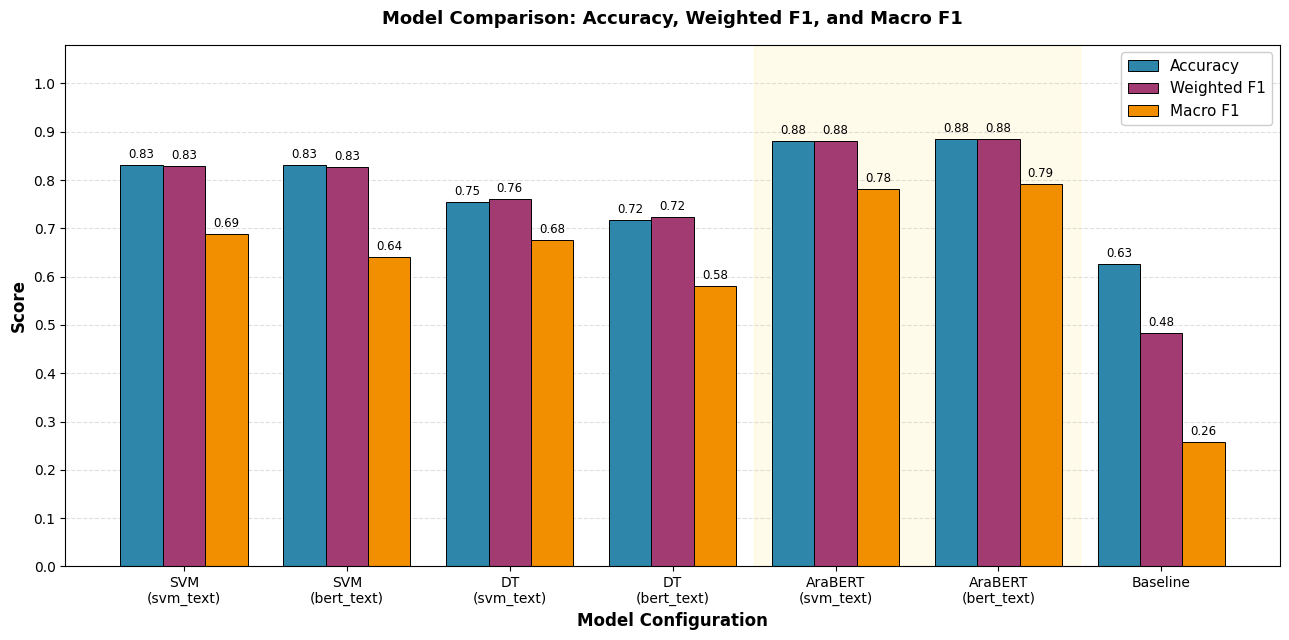


✅ انتهت الخلية 24


In [ ]:
# ============================================================
# CELL 24: توليد Table 4 v2 + Table 5 v2 + Figure 1 v2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("📊 توليد الجداول والرسم النهائي (v2)")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────
svm_dt = pd.read_csv("/content/seeds_summary_v2_SVM_DT.csv")
arabert = pd.read_csv("/content/seeds_summary_v2_AraBERT.csv")
baseline = pd.read_csv("/content/baseline_v2.csv")

# ── Table 4: Classification Performance ─────────────────
# ترتيب: SVM_svm، SVM_bert، DT_svm، DT_bert، AraBERT_svm، AraBERT_bert، Baseline

def get_row(df, model_name):
    row = df[df["model"] == model_name].iloc[0]
    return row

rows = []
for name, display in [
    ("SVM_svm_text", ("svm_text", "SVM")),
    ("SVM_bert_text", ("bert_text", "SVM")),
    ("DT_svm_text", ("svm_text", "Decision Tree")),
    ("DT_bert_text", ("bert_text", "Decision Tree")),
    ("AraBERT_svm_text", ("svm_text", "AraBERT")),
    ("AraBERT_bert_text", ("bert_text", "AraBERT")),
]:
    if name in svm_dt["model"].values:
        row = get_row(svm_dt, name)
    else:
        row = get_row(arabert, name)

    rows.append({
        "Text Input": display[0],
        "Classifier": display[1],
        "Accuracy": f"{row['accuracy_mean']:.4f} ± {row['accuracy_std']:.4f}",
        "Weighted F1": f"{row['f1_weighted_mean']:.4f} ± {row['f1_weighted_std']:.4f}",
        "Macro F1": f"{row['f1_macro_mean']:.4f} ± {row['f1_macro_std']:.4f}",
    })

# إضافة Baseline
rows.append({
    "Text Input": "—",
    "Classifier": "Majority Baseline",
    "Accuracy": f"{baseline['accuracy'].values[0]:.4f}",
    "Weighted F1": f"{baseline['f1_weighted'].values[0]:.4f}",
    "Macro F1": f"{baseline['f1_macro'].values[0]:.4f}",
})

table4 = pd.DataFrame(rows)
print("\n" + "="*70)
print("📊 Table 4: Classification Performance Comparison (v2)")
print("="*70)
print(table4.to_string(index=False))
table4.to_csv("/content/Table4_v2.csv", index=False)

# ── Table 5: Class-level F1 ─────────────────────────────
print("\n" + "="*70)
print("📊 Table 5: Class-level F1 (v2)")
print("="*70)

class_rows = []
for name, display in [
    ("SVM_svm_text", "SVM + svm_text"),
    ("SVM_bert_text", "SVM + bert_text"),
    ("DT_svm_text", "DT + svm_text"),
    ("DT_bert_text", "DT + bert_text"),
    ("AraBERT_svm_text", "AraBERT + svm_text"),
    ("AraBERT_bert_text", "AraBERT + bert_text"),
]:
    # حاجة لقراءة classification_report لكل موديل
    pred_file = f"/content/pred_v2_{name}.csv"
    pred_df = pd.read_csv(pred_file)
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    from sklearn.metrics import classification_report
    report = classification_report(
        y_true, y_pred,
        target_names=["supportive", "critical", "neutral"],
        output_dict=True, zero_division=0,
    )

    class_rows.append({
        "Model": display,
        "Supportive F1": round(report["supportive"]["f1-score"], 4),
        "Critical F1": round(report["critical"]["f1-score"], 4),
        "Neutral F1": round(report["neutral"]["f1-score"], 4),
        "Macro F1": round(report["macro avg"]["f1-score"], 4),
    })

table5 = pd.DataFrame(class_rows)
print(table5.to_string(index=False))
table5.to_csv("/content/Table5_v2.csv", index=False)

# ── Figure 1: Model Comparison ───────────────────────────
print("\n" + "="*70)
print("📈 توليد Figure 1 (v2)")
print("="*70)

models = [
    "SVM\n(svm_text)", "SVM\n(bert_text)",
    "DT\n(svm_text)", "DT\n(bert_text)",
    "AraBERT\n(svm_text)", "AraBERT\n(bert_text)",
    "Baseline",
]

# جمع القيم من Table4
acc_vals = []
wf1_vals = []
mf1_vals = []

for name, display in [
    ("SVM_svm_text", None),
    ("SVM_bert_text", None),
    ("DT_svm_text", None),
    ("DT_bert_text", None),
    ("AraBERT_svm_text", None),
    ("AraBERT_bert_text", None),
]:
    if name in svm_dt["model"].values:
        row = get_row(svm_dt, name)
    else:
        row = get_row(arabert, name)
    acc_vals.append(row["accuracy_mean"])
    wf1_vals.append(row["f1_weighted_mean"])
    mf1_vals.append(row["f1_macro_mean"])

# Baseline
acc_vals.append(baseline["accuracy"].values[0])
wf1_vals.append(baseline["f1_weighted"].values[0])
mf1_vals.append(baseline["f1_macro"].values[0])

# الرسم
fig, ax = plt.subplots(figsize=(13, 6.5))
x = np.arange(len(models))
width = 0.26

bars1 = ax.bar(x - width, acc_vals, width, label="Accuracy", color="#2E86AB", edgecolor="black", linewidth=0.7)
bars2 = ax.bar(x, wf1_vals, width, label="Weighted F1", color="#A23B72", edgecolor="black", linewidth=0.7)
bars3 = ax.bar(x + width, mf1_vals, width, label="Macro F1", color="#F18F01", edgecolor="black", linewidth=0.7)

def add_labels(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.annotate(f"{val:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8.5)

add_labels(bars1, acc_vals)
add_labels(bars2, wf1_vals)
add_labels(bars3, mf1_vals)

ax.set_xlabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title("Model Comparison: Accuracy, Weighted F1, and Macro F1",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.legend(loc="upper right", fontsize=11, framealpha=0.95)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# إبراز AraBERT
ax.axvspan(3.5, 5.5, alpha=0.08, color="gold", zorder=0)

plt.tight_layout()
plt.savefig("/content/Figure1_v2.png", dpi=300, bbox_inches="tight")
plt.savefig("/content/Figure1_v2.pdf", bbox_inches="tight")

print("✅ حفظنا:")
print("   /content/Table4_v2.csv")
print("   /content/Table5_v2.csv")
print("   /content/Figure1_v2.png")
print("   /content/Figure1_v2.pdf")

plt.show()

print("\n" + "="*70)
print("✅ انتهت الخلية 24")
print("="*70)

In [ ]:
# ============================================================
# CELL 2: رفع الملفات + قراءة البيانات
# ============================================================

from google.colab import files
import pandas as pd
import os

# ── STEP 1: رفع الملفات ─────────────────────────────────
print("="*70)
print("📤 ارفعي الملفات التالية:")
print("="*70)
print("  1. annotation fully completed.xlsx  ← الأساس")
print("  2. annotation_with_auto_labels.csv  ← للمقارنة")
print("  3. Tweets_Data.xlsx                 ← معلومات إضافية")
print("  4. collect_tweets.py                ← للـ appendix")
print("="*70)

uploaded = files.upload()

print("\n" + "="*70)
print(f"✅ تم رفع {len(uploaded)} ملف")
print("="*70)

for filename, content in uploaded.items():
    size_mb = len(content) / 1024 / 1024
    print(f"  {filename:55s}  {size_mb:8.2f} MB")

# ── STEP 2: قراءة ملف الـ annotation الرئيسي ──────────────
print("\n" + "="*70)
print("📖 قراءة annotation fully completed.xlsx")
print("="*70)

FILE_ANNOT = "/content/annotation fully completed.xlsx"

try:
    df = pd.read_excel(FILE_ANNOT, engine="calamine")
    print(f"✅ قرأ بنجاح بـ calamine")
except Exception as e:
    print(f"⚠️ calamine فشل: {e}")
    df = pd.read_excel(FILE_ANNOT)
    print(f"✅ قرأ بنجاح بـ openpyxl")

print(f"\nSHAPE: {df.shape}")
print(f"COLUMNS ({len(df.columns)}):")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")

# ── STEP 3: فحص سريع ─────────────────────────────────────
print("\n" + "="*70)
print("🔍 فحص سريع")
print("="*70)

print(f"\nعدد الصفوف: {len(df):,}")
print(f"عدد الأعمدة: {len(df.columns)}")
print(f"\nالقيم الفارغة في الأعمدة الحرجة:")
for col in ["tweet_id", "original_text", "svm_text", "bert_text", "adjudicated_label"]:
    if col in df.columns:
        nulls = df[col].isna().sum()
        print(f"  {col:25s}  nulls = {nulls}")

# ── STEP 4: توزيع adjudicated_label ──────────────────────
print("\n" + "="*70)
print("📊 توزيع adjudicated_label")
print("="*70)
if "adjudicated_label" in df.columns:
    print(df["adjudicated_label"].value_counts())

# ── STEP 5: أول 3 صفوف (كل الأعمدة) ─────────────────────
print("\n" + "="*70)
print("📄 أول صف واحد (كل الأعمدة)")
print("="*70)
for col in df.columns:
    val = str(df.iloc[0][col])[:200]
    print(f"  {col:35s} : {val}")

# ── STEP 6: حفظ الملفات ──────────────────────────────────
print("\n" + "="*70)
print("📂 كل الملفات في /content")
print("="*70)
for f in sorted(os.listdir("/content")):
    full = os.path.join("/content", f)
    if os.path.isfile(full):
        size_mb = os.path.getsize(full) / 1024 / 1024
        print(f"  {f:55s}  {size_mb:8.2f} MB")

print("\n" + "="*70)
print("✅ انتهت الخلية 2")
print("="*70)

📤 ارفعي الملفات التالية:
  1. annotation fully completed.xlsx  ← الأساس
  2. annotation_with_auto_labels.csv  ← للمقارنة
  3. Tweets_Data.xlsx                 ← معلومات إضافية
  4. collect_tweets.py                ← للـ appendix


Saving annotation fully completed.csv to annotation fully completed.csv
Saving annotation_with_auto_labels.csv to annotation_with_auto_labels.csv
Saving collect_tweets.py to collect_tweets.py
Saving Tweets_Data.xlsx to Tweets_Data.xlsx

✅ تم رفع 4 ملف
  annotation fully completed.csv                               2.68 MB
  annotation_with_auto_labels.csv                              9.63 MB
  collect_tweets.py                                            0.01 MB
  Tweets_Data.xlsx                                             2.15 MB

📖 قراءة annotation fully completed.xlsx
⚠️ calamine فشل: [Errno 2] No such file or directory: '/content/annotation fully completed.xlsx'


FileNotFoundError: [Errno 2] No such file or directory: '/content/annotation fully completed.xlsx'

In [ ]:
# ============================================================
# CELL 3: رفع annotation fully completed.xlsx
# ============================================================

from google.colab import files
import pandas as pd
import os

print("="*70)
print("📤 ارفعي ملف annotation fully completed.xlsx")
print("="*70)

uploaded = files.upload()

print("\n" + "="*70)
print("✅ تم الرفع")
print("="*70)

for filename, content in uploaded.items():
    size_mb = len(content) / 1024 / 1024
    print(f"  {filename:55s}  {size_mb:8.2f} MB")

# ── قراءة الملف ─────────────────────────────────────────
print("\n" + "="*70)
print("📖 قراءة annotation fully completed.xlsx")
print("="*70)

FILE = "/content/annotation fully completed.xlsx"

if not os.path.exists(FILE):
    print("⚠️ الملف ليس بالاسم المتوقع، نبحث...")
    for f in os.listdir("/content"):
        if "annotation" in f.lower() and f.endswith(".xlsx"):
            FILE = f"/content/{f}"
            print(f"✅ وجدنا: {FILE}")
            break

# ── محاولة 1: calamine ──────────────────────────────────
df = None
try:
    df = pd.read_excel(FILE, engine="calamine")
    print("✅ calamine نجح")
except Exception as e:
    print(f"⚠️ calamine: {str(e)[:100]}")

# ── محاولة 2: openpyxl ──────────────────────────────────
if df is None:
    try:
        df = pd.read_excel(FILE, engine="openpyxl")
        print("✅ openpyxl نجح")
    except Exception as e:
        print(f"⚠️ openpyxl: {str(e)[:100]}")

if df is None:
    raise ValueError("❌ فشل قراءة الملف")

# ── فحص النتائج ─────────────────────────────────────────
print(f"\nSHAPE: {df.shape}")
print(f"\nCOLUMNS ({len(df.columns)}):")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")

print(f"\n📊 dtypes:")
print(df.dtypes)

print(f"\n📄 أول 2 صفوف (أول 5 أعمدة):")
print(df.iloc[:2, :5])

# ── استخراج stance ─────────────────────────────────────
print("\n" + "="*70)
print("📊 استخراج stance من adjudicated_label")
print("="*70)

STANCES = ["supportive", "critical", "neutral"]
def extract_stance(x):
    x = str(x).lower().strip()
    for s in STANCES:
        if x.endswith(s):
            return s
    return "UNKNOWN"

df["stance"] = df["adjudicated_label"].apply(extract_stance)

print("\nتوزيع adjudicated_label:")
print(df["adjudicated_label"].value_counts())

print("\nتوزيع stance:")
print(df["stance"].value_counts())

print("\n" + "="*70)
print("✅ انتهت الخلية 3")
print("="*70)

📤 ارفعي ملف annotation fully completed.xlsx


Saving annotation fully completed.xlsx to annotation fully completed.xlsx

✅ تم الرفع
  annotation fully completed.xlsx                              2.68 MB

📖 قراءة annotation fully completed.xlsx
✅ calamine نجح

SHAPE: (8092, 21)

COLUMNS (21):
   1. tweet_id
   2. original_text
   3. svm_text
   4. bert_text
   5. topic
   6. category
   7. dimension
   8. domain_label
   9. stance_label
  10. auto_stance
  11. auto_confidence
  12. annotator_1_Domain_Category_label
  13. annotator_1_Stance_label
  14. Anotator_1_confidence
  15. Anootator_1_notes
  16. annotator_2_Domain_Category_label
  17. annotator_2_Stance_label
  18. Anotator_2_confidence
  19. Anootator_2_notes
  20. adjudicated_label
  21. annotation_status

📊 dtypes:
tweet_id                              int64
original_text                        object
svm_text                             object
bert_text                            object
topic                                object
category                             obje

In [ ]:
# ============================================================
# CELL 4: فحص شامل للبيانات + svm_text/bert_text
# ============================================================

import pandas as pd
import numpy as np
import re

print("="*70)
print("🔍 فحص جودة svm_text و bert_text")
print("="*70)

# ── STEP 1: عيّنات مقارنة ────────────────────────────────
print("\n📄 مقارنة original_text vs svm_text vs bert_text (أول 3 صفوف):")
print("="*70)

for i in range(3):
    print(f"\n{'─'*70}")
    print(f"صف #{i} — tweet_id = {df.iloc[i]['tweet_id']}")
    print(f"{'─'*70}")
    print(f"\n📝 original_text (طول={len(df.iloc[i]['original_text'])}):")
    print(f"   {df.iloc[i]['original_text'][:300]}")
    print(f"\n🔧 svm_text (طول={len(df.iloc[i]['svm_text'])}):")
    print(f"   {df.iloc[i]['svm_text'][:300]}")
    print(f"\n🤖 bert_text (طول={len(df.iloc[i]['bert_text'])}):")
    print(f"   {df.iloc[i]['bert_text'][:300]}")

# ── STEP 2: تحليل الفروقات ────────────────────────────────
print("\n" + "="*70)
print("📊 تحليل الفروقات")
print("="*70)

# قياس الأطوال
df["len_orig"] = df["original_text"].astype(str).str.len()
df["len_svm"] = df["svm_text"].astype(str).str.len()
df["len_bert"] = df["bert_text"].astype(str).str.len()

print(f"\nمتوسط الأطوال:")
print(f"  original_text : {df['len_orig'].mean():.1f} حرف")
print(f"  svm_text      : {df['len_svm'].mean():.1f} حرف")
print(f"  bert_text     : {df['len_bert'].mean():.1f} حرف")

# ── STEP 3: كشف مكونات التنظيف ────────────────────────────
print("\n" + "="*70)
print("🔍 كشف مكونات التنظيف في كل نسخة")
print("="*70)

# عناصر يجب البحث عنها
patterns = {
    "روابط (http/https)": r"https?://",
    "منشن (@user)": r"@\w+",
    "هاشتاق (#)": r"#\w+",
    "إيموجي": r"[\U0001F300-\U0001F9FF]",
    "تشكيل (fatha, damma...)": r"[\u064B-\u065F]",
    "تطويل (ـ)": r"\u0640",
    "تكرار أحرف (3+)": r"(.)\1{2,}",
    "علامات ترقيم": r"[،؛؟!.,;?]",
    "أرقام لاتينية": r"\d",
    "أرقام عربية": r"[\u0660-\u0669]",
    "ألف مقصورة (ى)": r"ى",
    "تاء مربوطة (ة)": r"ة",
}

print(f"\n{'العنصر':30s} | {'original':>10s} | {'svm_text':>10s} | {'bert_text':>10s}")
print("─" * 75)

for name, pattern in patterns.items():
    n_orig = df["original_text"].astype(str).str.contains(pattern, regex=True).sum()
    n_svm  = df["svm_text"].astype(str).str.contains(pattern, regex=True).sum()
    n_bert = df["bert_text"].astype(str).str.contains(pattern, regex=True).sum()
    print(f"{name:30s} | {n_orig:>10,} | {n_svm:>10,} | {n_bert:>10,}")

# ── STEP 4: هل svm_text و bert_text مختلفان دائمًا؟ ───────
print("\n" + "="*70)
print("🔍 المقارنة النهائية")
print("="*70)

same_svm_bert = (df["svm_text"].astype(str) == df["bert_text"].astype(str)).sum()
same_orig_bert = (df["original_text"].astype(str) == df["bert_text"].astype(str)).sum()
same_orig_svm = (df["original_text"].astype(str) == df["svm_text"].astype(str)).sum()

print(f"\nsvm_text == bert_text : {same_svm_bert:,} ({same_svm_bert/len(df)*100:.1f}%)")
print(f"original == bert_text : {same_orig_bert:,} ({same_orig_bert/len(df)*100:.1f}%)")
print(f"original == svm_text  : {same_orig_svm:,} ({same_orig_svm/len(df)*100:.1f}%)")

# ── STEP 5: توزيع أطوال النصوص ─────────────────────────────
print("\n" + "="*70)
print("📊 توزيع أطوال bert_text")
print("="*70)
print(df["len_bert"].describe())

# ── STEP 6: هل هناك فراغات؟ ────────────────────────────────
print("\n" + "="*70)
print("🔍 التحقق من الفراغات")
print("="*70)

print(f"svm_text  فارغ : {(df['svm_text'].astype(str).str.strip() == '').sum()}")
print(f"bert_text فارغ : {(df['bert_text'].astype(str).str.strip() == '').sum()}")

# ── STEP 7: حفظ نسخة نظيفة ────────────────────────────────
# احذف الأعمدة المؤقتة
df = df.drop(columns=["len_orig", "len_svm", "len_bert"])

df.to_csv("/content/annotations_clean.csv", index=False, encoding="utf-8-sig")
print("\n✅ حفظنا نسخة نظيفة: annotations_clean.csv")

print("\n" + "="*70)
print("✅ انتهت الخلية 4")
print("="*70)

🔍 فحص جودة svm_text و bert_text

📄 مقارنة original_text vs svm_text vs bert_text (أول 3 صفوف):

──────────────────────────────────────────────────────────────────────
صف #0 — tweet_id = 2038918016407081037
──────────────────────────────────────────────────────────────────────

📝 original_text (طول=168):
   أربعاء الانبعاث رسالة واضحة أن الجنوب بقيادة عيدروس وبسند الإمارات يمضي بثبات نحو الاستقلال ويقهر الوصاية بالسلمية ومشاريع تنمية تحفظ كرامة شعبه https://t.co/SV6CRvyAcB

🔧 svm_text (طول=130):
   الانبعاث رساله واضحه الجنوب بقياده عيدروس وبسند الامارات يمضي بثبات الاستقلال ويقهر الوصايه بالسلميه ومشاريع تنميه تحفظ كرامه شعبه

🤖 bert_text (طول=144):
   أربعاء الانبعاث رسالة واضحة أن الجنوب بقيادة عيدروس وبسند الإمارات يمضي بثبات نحو الاستقلال ويقهر الوصاية بالسلمية ومشاريع تنمية تحفظ كرامة شعبه

──────────────────────────────────────────────────────────────────────
صف #1 — tweet_id = 2038848573954298085
──────────────────────────────────────────────────────────────────────

📝 original_

/tmp/ipykernel_987/3327794282.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_orig = df["original_text"].astype(str).str.contains(pattern, regex=True).sum()
/tmp/ipykernel_987/3327794282.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_svm  = df["svm_text"].astype(str).str.contains(pattern, regex=True).sum()
/tmp/ipykernel_987/3327794282.py:70: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_bert = df["bert_text"].astype(str).str.contains(pattern, regex=True).sum()


تكرار أحرف (3+)                |        433 |        821 |        312
علامات ترقيم                   |      7,874 |      4,283 |      5,970
أرقام لاتينية                  |      6,780 |      2,976 |      3,135
أرقام عربية                    |        127 |        109 |        127
ألف مقصورة (ى)                 |      4,365 |          0 |      4,365
تاء مربوطة (ة)                 |      7,874 |          0 |      7,874

🔍 المقارنة النهائية

svm_text == bert_text : 0 (0.0%)
original == bert_text : 218 (2.7%)
original == svm_text  : 0 (0.0%)

📊 توزيع أطوال bert_text
count    8092.000000
mean      212.747899
std        64.604140
min        34.000000
25%       167.000000
50%       235.000000
75%       271.000000
max       283.000000
Name: len_bert, dtype: float64

🔍 التحقق من الفراغات
svm_text  فارغ : 0
bert_text فارغ : 0

✅ حفظنا نسخة نظيفة: annotations_clean.csv

✅ انتهت الخلية 4


In [ ]:
# ============================================================
# CELL 5: تحضير البيانات + Split 80/10/10
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("="*70)
print("🔧 تحضير البيانات للتدريب")
print("="*70)

# ── STEP 1: استخراج stance ────────────────────────────────
STANCES = ["supportive", "critical", "neutral"]
def extract_stance(x):
    x = str(x).lower().strip()
    for s in STANCES:
        if x.endswith(s):
            return s
    return "UNKNOWN"

df["stance"] = df["adjudicated_label"].apply(extract_stance)

# ── STEP 2: تحويل التصنيفات لأرقام ────────────────────────
LABEL2ID = {"supportive": 0, "critical": 1, "neutral": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df["label"] = df["stance"].map(LABEL2ID)

print(f"\n✅ تم استخراج stance وتحويله لأرقام")
print(f"   توزيع label النهائي:")
for name, idx in LABEL2ID.items():
    count = (df["label"] == idx).sum()
    print(f"   {idx} = {name:12s} : {count:5,} ({count/len(df)*100:.2f}%)")

# ── STEP 3: حذف الصفوف بدون نص ────────────────────────────
print(f"\n📊 قبل التنظيف: {len(df):,}")

# احذف الصفوف التي stance = UNKNOWN
df = df[df["label"].notna()].copy()

# احذف الصفوف الفارغة في svm_text/bert_text
df = df[df["svm_text"].astype(str).str.strip() != ""].copy()
df = df[df["bert_text"].astype(str).str.strip() != ""].copy()

df = df.reset_index(drop=True)
print(f"📊 بعد التنظيف: {len(df):,}")

# ── STEP 4: Split 80/10/10 ────────────────────────────────
print("\n" + "="*70)
print("✂️ تقسيم البيانات: 80% train / 10% val / 10% test")
print("="*70)

# Split الأول: 80% train، 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

# Split الثاني: temp → 50% val، 50% test (10%/10% من الأصلي)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n✅ Train : {len(train_df):5,}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"✅ Val   : {len(val_df):5,}  ({len(val_df)/len(df)*100:.1f}%)")
print(f"✅ Test  : {len(test_df):5,}  ({len(test_df)/len(df)*100:.1f}%)")
print(f"✅ TOTAL : {len(df):5,}")

# ── STEP 5: التحقق من التوزيع ────────────────────────────
print("\n" + "="*70)
print("📊 توزيع label في كل split:")
print("="*70)

print(f"\n{'class':12s} | {'train':>8s} | {'val':>8s} | {'test':>8s}")
print("─" * 50)

for name, idx in LABEL2ID.items():
    n_train = (train_df["label"] == idx).sum()
    n_val = (val_df["label"] == idx).sum()
    n_test = (test_df["label"] == idx).sum()
    print(f"{name:12s} | {n_train:>8,} | {n_val:>8,} | {n_test:>8,}")

# ── STEP 6: حفظ الملفات ───────────────────────────────────
train_df.to_csv("/content/train.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("/content/val.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("/content/test.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ حفظنا:")
print(f"   /content/train.csv")
print(f"   /content/val.csv")
print(f"   /content/test.csv")

# ── STEP 7: حفظ LABEL2ID لاستخدامه لاحقًا ────────────────
import json
with open("/content/label_mappings.json", "w") as f:
    json.dump({"label2id": LABEL2ID, "id2label": ID2LABEL}, f)

print(f"✅ حفظنا: /content/label_mappings.json")

print("\n" + "="*70)
print("✅ انتهت الخلية 5")
print("="*70)

🔧 تحضير البيانات للتدريب

✅ تم استخراج stance وتحويله لأرقام
   توزيع label النهائي:
   0 = supportive   : 5,113 (63.19%)
   1 = critical     :   165 (2.04%)
   2 = neutral      : 2,814 (34.78%)

📊 قبل التنظيف: 8,092
📊 بعد التنظيف: 8,092

✂️ تقسيم البيانات: 80% train / 10% val / 10% test

✅ Train : 6,473  (80.0%)
✅ Val   :   809  (10.0%)
✅ Test  :   810  (10.0%)
✅ TOTAL : 8,092

📊 توزيع label في كل split:

class        |    train |      val |     test
──────────────────────────────────────────────────
supportive   |    4,090 |      511 |      512
critical     |      132 |       17 |       16
neutral      |    2,251 |      281 |      282

✅ حفظنا:
   /content/train.csv
   /content/val.csv
   /content/test.csv
✅ حفظنا: /content/label_mappings.json

✅ انتهت الخلية 5


In [ ]:
# ============================================================
# CELL 6: SVM على svm_text (TF-IDF + LinearSVC)
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print("="*70)
print("🤖 SVM على svm_text")
print("="*70)

# ── STEP 1: قراءة البيانات ────────────────────────────────
train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

# تعويض أي NaN محتمل
for d in [train_df, val_df, test_df]:
    d["svm_text"] = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

X_train = train_df["svm_text"].values
y_train = train_df["label"].values

X_val = val_df["svm_text"].values
y_val = val_df["label"].values

X_test = test_df["svm_text"].values
y_test = test_df["label"].values

print(f"\nTrain: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# ── STEP 2: TF-IDF (وفق إعدادات الريبورت 5.6.1) ────────────
print("\n" + "="*70)
print("🔧 TF-IDF Settings")
print("="*70)
print("  max_features = 20,000")
print("  ngram_range  = (1, 2)")
print("  min_df       = 2")
print("  sublinear_tf = True")

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

t0 = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)   # fit فقط على train
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f"\n✅ TF-IDF fit → {X_train_tfidf.shape[1]:,} features (وقت: {time.time()-t0:.1f}s)")

# ── STEP 3: LinearSVC (وفق إعدادات الريبورت 5.6.1) ─────────
print("\n" + "="*70)
print("🚀 تدريب LinearSVC")
print("="*70)
print("  class_weight = balanced")
print("  random_state = 42")
print("  max_iter     = 5000")

clf = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000,
)

t0 = time.time()
clf.fit(X_train_tfidf, y_train)
print(f"✅ تدريب انتهى (وقت: {time.time()-t0:.1f}s)")

# ── STEP 4: تقييم على val ─────────────────────────────────
y_val_pred = clf.predict(X_val_tfidf)

print("\n" + "="*70)
print("📊 Validation Results")
print("="*70)

val_acc = accuracy_score(y_val, y_val_pred)
val_prec_w = precision_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_rec_w  = recall_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_f1_w   = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_f1_mac = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print(f"  Accuracy          : {val_acc:.4f}")
print(f"  Weighted F1       : {val_f1_w:.4f}")
print(f"  Macro F1          : {val_f1_mac:.4f}")

# ── STEP 5: تقييم على test ────────────────────────────────
y_test_pred = clf.predict(X_test_tfidf)

print("\n" + "="*70)
print("📊 Test Results")
print("="*70)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec_w = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_rec_w  = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_w   = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_mac = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

print(f"  Accuracy          : {test_acc:.4f}")
print(f"  Weighted Precision: {test_prec_w:.4f}")
print(f"  Weighted Recall   : {test_rec_w:.4f}")
print(f"  Weighted F1       : {test_f1_w:.4f}")
print(f"  Macro F1          : {test_f1_mac:.4f}")

# ── STEP 6: تقرير تفصيلي لكل class ────────────────────────
print("\n" + "="*70)
print("📋 Classification Report (Test)")
print("="*70)

LABEL_NAMES = ["supportive", "critical", "neutral"]
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

# ── STEP 7: Confusion Matrix ──────────────────────────────
print("="*70)
print("📊 Confusion Matrix (Test)")
print("="*70)

cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES)
print(cm_df)

# ── STEP 8: حفظ النتائج ────────────────────────────────────
results = {
    "model": "SVM_svm_text",
    "val_accuracy": val_acc,
    "val_f1_weighted": val_f1_w,
    "val_f1_macro": val_f1_mac,
    "test_accuracy": test_acc,
    "test_precision_weighted": test_prec_w,
    "test_recall_weighted": test_rec_w,
    "test_f1_weighted": test_f1_w,
    "test_f1_macro": test_f1_mac,
}
pd.DataFrame([results]).to_csv("/content/result_SVM_svm_text.csv", index=False)

# حفظ predictions
pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
}).to_csv("/content/pred_SVM_svm_text.csv", index=False)

print("\n✅ حفظنا:")
print("   /content/result_SVM_svm_text.csv")
print("   /content/pred_SVM_svm_text.csv")

print("\n" + "="*70)
print("✅ انتهت الخلية 6")
print("="*70)

🤖 SVM على svm_text

Train: 6,473 | Val: 809 | Test: 810

🔧 TF-IDF Settings
  max_features = 20,000
  ngram_range  = (1, 2)
  min_df       = 2
  sublinear_tf = True

✅ TF-IDF fit → 20,000 features (وقت: 2.0s)

🚀 تدريب LinearSVC
  class_weight = balanced
  random_state = 42
  max_iter     = 5000
✅ تدريب انتهى (وقت: 0.5s)

📊 Validation Results
  Accuracy          : 0.9011
  Weighted F1       : 0.8984
  Macro F1          : 0.7717

📊 Test Results
  Accuracy          : 0.8975
  Weighted Precision: 0.8963
  Weighted Recall   : 0.8975
  Weighted F1       : 0.8956
  Macro F1          : 0.7622

📋 Classification Report (Test)
              precision    recall  f1-score   support

  supportive     0.9262    0.9316    0.9289       512
    critical     0.7500    0.3750    0.5000        16
     neutral     0.8502    0.8652    0.8576       282

    accuracy                         0.8975       810
   macro avg     0.8421    0.7240    0.7622       810
weighted avg     0.8963    0.8975    0.8956       8

In [ ]:
# ============================================================
# CELL 7: SVM على bert_text (نفس الإعدادات، نص مختلف)
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print("="*70)
print("🤖 SVM على bert_text")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────────
train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

X_train = train_df["bert_text"].values   # ← bert_text هنا
y_train = train_df["label"].values

X_val   = val_df["bert_text"].values
y_val   = val_df["label"].values

X_test  = test_df["bert_text"].values
y_test  = test_df["label"].values

print(f"\nTrain: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# ── TF-IDF ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f"\n✅ TF-IDF fit → {X_train_tfidf.shape[1]:,} features")

# ── LinearSVC ──────────────────────────────────────────────
clf = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000,
)

t0 = time.time()
clf.fit(X_train_tfidf, y_train)
print(f"✅ تدريب انتهى (وقت: {time.time()-t0:.1f}s)")

# ── Validation ────────────────────────────────────────────
y_val_pred = clf.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1_w = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_f1_mac = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print(f"\n📊 Validation:")
print(f"  Accuracy    : {val_acc:.4f}")
print(f"  Weighted F1 : {val_f1_w:.4f}")
print(f"  Macro F1    : {val_f1_mac:.4f}")

# ── Test ──────────────────────────────────────────────────
y_test_pred = clf.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec_w = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_rec_w  = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_w   = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_mac = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

print(f"\n📊 Test:")
print(f"  Accuracy           : {test_acc:.4f}")
print(f"  Weighted Precision : {test_prec_w:.4f}")
print(f"  Weighted Recall    : {test_rec_w:.4f}")
print(f"  Weighted F1        : {test_f1_w:.4f}")
print(f"  Macro F1           : {test_f1_mac:.4f}")

# ── Classification Report ────────────────────────────────
LABEL_NAMES = ["supportive", "critical", "neutral"]
print("\n📋 Classification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

# ── Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
print("📊 Confusion Matrix (Test):")
print(pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES))

# ── حفظ النتائج ──────────────────────────────────────────
results = {
    "model": "SVM_bert_text",
    "val_accuracy": val_acc,
    "val_f1_weighted": val_f1_w,
    "val_f1_macro": val_f1_mac,
    "test_accuracy": test_acc,
    "test_precision_weighted": test_prec_w,
    "test_recall_weighted": test_rec_w,
    "test_f1_weighted": test_f1_w,
    "test_f1_macro": test_f1_mac,
}
pd.DataFrame([results]).to_csv("/content/result_SVM_bert_text.csv", index=False)

pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
}).to_csv("/content/pred_SVM_bert_text.csv", index=False)

print("\n✅ حفظنا: result_SVM_bert_text.csv + pred_SVM_bert_text.csv")
print("="*70)

🤖 SVM على bert_text

Train: 6,473 | Val: 809 | Test: 810

✅ TF-IDF fit → 20,000 features
✅ تدريب انتهى (وقت: 0.2s)

📊 Validation:
  Accuracy    : 0.8888
  Weighted F1 : 0.8860
  Macro F1    : 0.7556

📊 Test:
  Accuracy           : 0.8864
  Weighted Precision : 0.8843
  Weighted Recall    : 0.8864
  Weighted F1        : 0.8843
  Macro F1           : 0.7267

📋 Classification Report (Test):
              precision    recall  f1-score   support

  supportive     0.9220    0.9238    0.9229       512
    critical     0.6250    0.3125    0.4167        16
     neutral     0.8304    0.8511    0.8406       282

    accuracy                         0.8864       810
   macro avg     0.7925    0.6958    0.7267       810
weighted avg     0.8843    0.8864    0.8843       810

📊 Confusion Matrix (Test):
            supportive  critical  neutral
supportive         473         0       39
critical             1         5       10
neutral             39         3      240

✅ حفظنا: result_SVM_bert_text.cs

In [ ]:
# ============================================================
# CELL 8: Decision Tree على svm_text
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print("="*70)
print("🌳 Decision Tree على svm_text")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────────
train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

X_train = train_df["svm_text"].values
y_train = train_df["label"].values
X_val   = val_df["svm_text"].values
y_val   = val_df["label"].values
X_test  = test_df["svm_text"].values
y_test  = test_df["label"].values

# ── TF-IDF (نفس الإعدادات) ─────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f"✅ TF-IDF: {X_train_tfidf.shape[1]:,} features")

# ── Decision Tree (وفق إعدادات الريبورت 5.6.2) ─────────────
print("\n🌳 إعدادات Decision Tree:")
print("  max_depth          = 30")
print("  min_samples_split  = 5")
print("  class_weight       = balanced")
print("  random_state       = 42")

clf = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
)

t0 = time.time()
clf.fit(X_train_tfidf, y_train)
print(f"\n✅ تدريب انتهى (وقت: {time.time()-t0:.1f}s)")

# ── Validation ────────────────────────────────────────────
y_val_pred = clf.predict(X_val_tfidf)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1_w = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_f1_mac = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print(f"\n📊 Validation:")
print(f"  Accuracy    : {val_acc:.4f}")
print(f"  Weighted F1 : {val_f1_w:.4f}")
print(f"  Macro F1    : {val_f1_mac:.4f}")

# ── Test ──────────────────────────────────────────────────
y_test_pred = clf.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec_w = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_rec_w  = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_w   = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_mac = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

print(f"\n📊 Test:")
print(f"  Accuracy           : {test_acc:.4f}")
print(f"  Weighted Precision : {test_prec_w:.4f}")
print(f"  Weighted Recall    : {test_rec_w:.4f}")
print(f"  Weighted F1        : {test_f1_w:.4f}")
print(f"  Macro F1           : {test_f1_mac:.4f}")

# ── Classification Report ────────────────────────────────
LABEL_NAMES = ["supportive", "critical", "neutral"]
print("\n📋 Classification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

# ── Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
print("📊 Confusion Matrix (Test):")
print(pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES))

# ── حفظ النتائج ──────────────────────────────────────────
results = {
    "model": "DT_svm_text",
    "val_accuracy": val_acc,
    "val_f1_weighted": val_f1_w,
    "val_f1_macro": val_f1_mac,
    "test_accuracy": test_acc,
    "test_precision_weighted": test_prec_w,
    "test_recall_weighted": test_rec_w,
    "test_f1_weighted": test_f1_w,
    "test_f1_macro": test_f1_mac,
}
pd.DataFrame([results]).to_csv("/content/result_DT_svm_text.csv", index=False)

pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
}).to_csv("/content/pred_DT_svm_text.csv", index=False)

print("\n✅ حفظنا: result_DT_svm_text.csv + pred_DT_svm_text.csv")
print("="*70)

🌳 Decision Tree على svm_text
✅ TF-IDF: 20,000 features

🌳 إعدادات Decision Tree:
  max_depth          = 30
  min_samples_split  = 5
  class_weight       = balanced
  random_state       = 42

✅ تدريب انتهى (وقت: 1.3s)

📊 Validation:
  Accuracy    : 0.7775
  Weighted F1 : 0.7842
  Macro F1    : 0.6734

📊 Test:
  Accuracy           : 0.7889
  Weighted Precision : 0.8329
  Weighted Recall    : 0.7889
  Weighted F1        : 0.7968
  Macro F1           : 0.6869

📋 Classification Report (Test):
              precision    recall  f1-score   support

  supportive     0.9454    0.7441    0.8328       512
    critical     0.3667    0.6875    0.4783        16
     neutral     0.6552    0.8759    0.7496       282

    accuracy                         0.7889       810
   macro avg     0.6557    0.7692    0.6869       810
weighted avg     0.8329    0.7889    0.7968       810

📊 Confusion Matrix (Test):
            supportive  critical  neutral
supportive         381         6      125
critical       

In [ ]:
# ============================================================
# CELL 9: Decision Tree على bert_text
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print("="*70)
print("🌳 Decision Tree على bert_text")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────────
train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

X_train = train_df["bert_text"].values
y_train = train_df["label"].values
X_val   = val_df["bert_text"].values
y_val   = val_df["label"].values
X_test  = test_df["bert_text"].values
y_test  = test_df["label"].values

# ── TF-IDF ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)
print(f"✅ TF-IDF: {X_train_tfidf.shape[1]:,} features")

# ── Decision Tree ──────────────────────────────────────────
clf = DecisionTreeClassifier(
    max_depth=30,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
)

t0 = time.time()
clf.fit(X_train_tfidf, y_train)
print(f"✅ تدريب انتهى (وقت: {time.time()-t0:.1f}s)")

# ── Validation ────────────────────────────────────────────
y_val_pred = clf.predict(X_val_tfidf)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1_w = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
val_f1_mac = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print(f"\n📊 Validation:")
print(f"  Accuracy    : {val_acc:.4f}")
print(f"  Weighted F1 : {val_f1_w:.4f}")
print(f"  Macro F1    : {val_f1_mac:.4f}")

# ── Test ──────────────────────────────────────────────────
y_test_pred = clf.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec_w = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_rec_w  = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_w   = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_mac = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

print(f"\n📊 Test:")
print(f"  Accuracy           : {test_acc:.4f}")
print(f"  Weighted Precision : {test_prec_w:.4f}")
print(f"  Weighted Recall    : {test_rec_w:.4f}")
print(f"  Weighted F1        : {test_f1_w:.4f}")
print(f"  Macro F1           : {test_f1_mac:.4f}")

# ── Classification Report ────────────────────────────────
LABEL_NAMES = ["supportive", "critical", "neutral"]
print("\n📋 Classification Report (Test):")
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

# ── Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
print("📊 Confusion Matrix (Test):")
print(pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES))

# ── حفظ ──────────────────────────────────────────────────
results = {
    "model": "DT_bert_text",
    "val_accuracy": val_acc,
    "val_f1_weighted": val_f1_w,
    "val_f1_macro": val_f1_mac,
    "test_accuracy": test_acc,
    "test_precision_weighted": test_prec_w,
    "test_recall_weighted": test_rec_w,
    "test_f1_weighted": test_f1_w,
    "test_f1_macro": test_f1_mac,
}
pd.DataFrame([results]).to_csv("/content/result_DT_bert_text.csv", index=False)

pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
}).to_csv("/content/pred_DT_bert_text.csv", index=False)

print("\n✅ حفظنا: result_DT_bert_text.csv + pred_DT_bert_text.csv")
print("="*70)

🌳 Decision Tree على bert_text
✅ TF-IDF: 20,000 features
✅ تدريب انتهى (وقت: 1.5s)

📊 Validation:
  Accuracy    : 0.7305
  Weighted F1 : 0.7391
  Macro F1    : 0.6003

📊 Test:
  Accuracy           : 0.7568
  Weighted Precision : 0.8070
  Weighted Recall    : 0.7568
  Weighted F1        : 0.7658
  Macro F1           : 0.6512

📋 Classification Report (Test):
              precision    recall  f1-score   support

  supportive     0.9262    0.7109    0.8044       512
    critical     0.3333    0.6250    0.4348        16
     neutral     0.6176    0.8475    0.7145       282

    accuracy                         0.7568       810
   macro avg     0.6257    0.7278    0.6512       810
weighted avg     0.8070    0.7568    0.7658       810

📊 Confusion Matrix (Test):
            supportive  critical  neutral
supportive         364         6      142
critical             0        10        6
neutral             29        14      239

✅ حفظنا: result_DT_bert_text.csv + pred_DT_bert_text.csv


In [ ]:
# ============================================================
# CELL 10a: تحميل AraBERT
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("="*70)
print("🤖 تحميل AraBERT")
print("="*70)

MODEL_NAME = "aubmindlab/bert-base-arabertv02-twitter"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"✅ Tokenizer محمّل")
print(f"   Vocab size: {tokenizer.vocab_size:,}")
print(f"   Model max length: {tokenizer.model_max_length}")

# نموذج فارغ سنُدرّبه لاحقًا
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: "supportive", 1: "critical", 2: "neutral"},
    label2id={"supportive": 0, "critical": 1, "neutral": 2},
)

# نقل النموذج إلى GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"\n✅ Model محمّل على {device}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

# اختبار سريع
sample = "الإمارات تقود جهود الاستدامة في المنطقة"
tokens = tokenizer(sample, return_tensors="pt", truncation=True, max_length=128)
tokens = {k: v.to(device) for k, v in tokens.items()}
with torch.no_grad():
    logits = model(**tokens).logits
print(f"\n✅ اختبار سريع نجح")
print(f"   Input: {sample}")
print(f"   Logits shape: {logits.shape}")

🤖 تحميل AraBERT


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/751k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model محمّل على cuda
   Parameters: 135,195,651

✅ اختبار سريع نجح
   Input: الإمارات تقود جهود الاستدامة في المنطقة
   Logits shape: torch.Size([1, 3])


In [ ]:
# ============================================================
# CELL 10b: تجهيز PyTorch Dataset + Class Weights
# ============================================================

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight

print("="*70)
print("🔧 تجهيز Dataset للتدريب")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────────
train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

# ── PyTorch Dataset ────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── Class Weights (لحل مشكلة عدم التوازن) ─────────────────
print("\n" + "="*70)
print("⚖️ حساب Class Weights من Training Data")
print("="*70)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"].values,
)

print(f"\nClass Weights:")
for i, w in enumerate(class_weights):
    label_name = ["supportive", "critical", "neutral"][i]
    print(f"  {i} = {label_name:12s} : {w:.4f}")

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"\n✅ Tensor: {class_weights_tensor}")

# ── إنشاء Datasets ────────────────────────────────────────
MAX_LEN = 128
BATCH_SIZE = 16

def make_dataset(text_col):
    train_ds = TweetDataset(train_df[text_col].values, train_df["label"].values, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(val_df[text_col].values,   val_df["label"].values,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(test_df[text_col].values,  test_df["label"].values,  tokenizer, MAX_LEN)
    return train_ds, val_ds, test_ds

train_ds_svm, val_ds_svm, test_ds_svm = make_dataset("svm_text")
train_ds_bert, val_ds_bert, test_ds_bert = make_dataset("bert_text")

print(f"\n✅ Datasets جاهزة:")
print(f"   Train: {len(train_ds_svm):,}")
print(f"   Val  : {len(val_ds_svm):,}")
print(f"   Test : {len(test_ds_svm):,}")

# ── اختبار Dataset ────────────────────────────────────────
print(f"\n✅ اختبار Dataset:")
sample = train_ds_svm[0]
print(f"   input_ids shape     : {sample['input_ids'].shape}")
print(f"   attention_mask shape: {sample['attention_mask'].shape}")
print(f"   labels shape        : {sample['labels'].shape}")
print(f"   label value         : {sample['labels'].item()}")

print("\n" + "="*70)
print("✅ انتهت الخلية 10b")
print("="*70)

🔧 تجهيز Dataset للتدريب

⚖️ حساب Class Weights من Training Data

Class Weights:
  0 = supportive   : 0.5275
  1 = critical     : 16.3460
  2 = neutral      : 0.9585

✅ Tensor: tensor([ 0.5275, 16.3460,  0.9585], device='cuda:0')

✅ Datasets جاهزة:
   Train: 6,473
   Val  : 809
   Test : 810

✅ اختبار Dataset:
   input_ids shape     : torch.Size([128])
   attention_mask shape: torch.Size([128])
   labels shape        : torch.Size([])
   label value         : 0

✅ انتهت الخلية 10b


In [ ]:
# ============================================================
# CELL 10c: تدريب AraBERT على svm_text
# ============================================================

import torch
import numpy as np
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

print("="*70)
print("🚀 تدريب AraBERT على svm_text")
print("="*70)

# ── إعدادات التدريب (وفق الريبورت 5.6.3) ──────────────────
EPOCHS = 3
BATCH_SIZE = 16
LR = 2e-5
WEIGHT_DECAY = 0.01
MAX_LEN = 128
SEED = 42

# ── ضبط البذور ───────────────────────────────────────────
def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ── إعادة تحميل النموذج (نظيف للتدريب) ────────────────────
MODEL_NAME = "aubmindlab/bert-base-arabertv02-twitter"
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: "supportive", 1: "critical", 2: "neutral"},
    label2id={"supportive": 0, "critical": 1, "neutral": 2},
).to(device)

# ── DataLoaders ───────────────────────────────────────────
train_loader = DataLoader(train_ds_svm, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds_svm,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds_svm,  batch_size=BATCH_SIZE, shuffle=False)

# ── Optimizer + Scheduler ─────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

# ── Loss function مع class weights ────────────────────────
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── دالة التقييم ──────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1_w = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1_mac = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_mac,
        "preds": all_preds,
        "labels": all_labels,
    }

# ── حلقة التدريب ──────────────────────────────────────────
print(f"\n📋 إعدادات:")
print(f"   Epochs         : {EPOCHS}")
print(f"   Batch size     : {BATCH_SIZE}")
print(f"   Learning rate  : {LR}")
print(f"   Weight decay   : {WEIGHT_DECAY}")
print(f"   Max length     : {MAX_LEN}")
print(f"   Total steps    : {total_steps}")
print(f"\n⏱️ بدء التدريب...\n")

best_val_f1_macro = 0.0
best_state = None
best_epoch = -1

import time
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    for step, batch in enumerate(train_loader, 1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if step % 100 == 0:
            print(f"   Epoch {epoch} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = epoch_loss / len(train_loader)

    # ── تقييم ───────────────────────────────────────────────
    val_metrics = evaluate(model, val_loader)

    print(f"\n{'─'*70}")
    print(f"📊 Epoch {epoch} — {time.time()-epoch_start:.1f}s")
    print(f"{'─'*70}")
    print(f"   Train Loss    : {train_loss:.4f}")
    print(f"   Val Loss      : {val_metrics['loss']:.4f}")
    print(f"   Val Accuracy  : {val_metrics['accuracy']:.4f}")
    print(f"   Val F1 (W)    : {val_metrics['f1_weighted']:.4f}")
    print(f"   Val F1 (Macro): {val_metrics['f1_macro']:.4f}")

    # ── اختيار best epoch حسب Val Macro F1 ────────────────
    if val_metrics["f1_macro"] > best_val_f1_macro:
        best_val_f1_macro = val_metrics["f1_macro"]
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"   ⭐ New best epoch! (Macro F1 = {best_val_f1_macro:.4f})")

    print()

print("="*70)
print(f"✅ انتهى التدريب (وقت كلي: {time.time()-start:.1f}s)")
print(f"🏆 Best epoch: {best_epoch} (Val Macro F1 = {best_val_f1_macro:.4f})")
print("="*70)

# ── استرجاع أفضل نموذج ────────────────────────────────────
model.load_state_dict(best_state)
model.to(device)

# ── تقييم نهائي على test ──────────────────────────────────
print("\n" + "="*70)
print("📊 Test Final Evaluation")
print("="*70)

test_metrics = evaluate(model, test_loader)

print(f"\n   Test Loss      : {test_metrics['loss']:.4f}")
print(f"   Test Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"   Test F1 (W)    : {test_metrics['f1_weighted']:.4f}")
print(f"   Test F1 (Macro): {test_metrics['f1_macro']:.4f}")

# ── حفظ النموذج ───────────────────────────────────────────
model.save_pretrained("/content/arabert_svm_text")
tokenizer.save_pretrained("/content/arabert_svm_text")
print(f"\n✅ حفظ النموذج: /content/arabert_svm_text/")

# ── حفظ النتائج ──────────────────────────────────────────
results = {
    "model": "AraBERT_svm_text",
    "best_epoch": best_epoch,
    "val_f1_macro": best_val_f1_macro,
    "test_accuracy": test_metrics["accuracy"],
    "test_f1_weighted": test_metrics["f1_weighted"],
    "test_f1_macro": test_metrics["f1_macro"],
}
pd.DataFrame([results]).to_csv("/content/result_AraBERT_svm_text.csv", index=False)

pd.DataFrame({
    "y_true": test_metrics["labels"],
    "y_pred": test_metrics["preds"],
}).to_csv("/content/pred_AraBERT_svm_text.csv", index=False)

print("✅ حفظ: result_AraBERT_svm_text.csv + pred_AraBERT_svm_text.csv")
print("="*70)

🚀 تدريب AraBERT على svm_text


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📋 إعدادات:
   Epochs         : 3
   Batch size     : 16
   Learning rate  : 2e-05
   Weight decay   : 0.01
   Max length     : 128
   Total steps    : 1215

⏱️ بدء التدريب...

   Epoch 1 | Step 100/405 | Loss: 0.7046
   Epoch 1 | Step 200/405 | Loss: 0.2201
   Epoch 1 | Step 300/405 | Loss: 0.7234
   Epoch 1 | Step 400/405 | Loss: 0.2347

──────────────────────────────────────────────────────────────────────
📊 Epoch 1 — 157.8s
──────────────────────────────────────────────────────────────────────
   Train Loss    : 0.8226
   Val Loss      : 0.6758
   Val Accuracy  : 0.8665
   Val F1 (W)    : 0.8651
   Val F1 (Macro): 0.7208
   ⭐ New best epoch! (Macro F1 = 0.7208)

   Epoch 2 | Step 100/405 | Loss: 0.5426
   Epoch 2 | Step 200/405 | Loss: 1.7996
   Epoch 2 | Step 300/405 | Loss: 1.2751
   Epoch 2 | Step 400/405 | Loss: 4.4087

──────────────────────────────────────────────────────────────────────
📊 Epoch 2 — 161.3s
──────────────────────────────────────────────────────────────────────

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ حفظ النموذج: /content/arabert_svm_text/
✅ حفظ: result_AraBERT_svm_text.csv + pred_AraBERT_svm_text.csv


In [ ]:
# ============================================================
# CELL 10d: تدريب AraBERT على bert_text
# ============================================================

import torch
import numpy as np
import time
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

print("="*70)
print("🚀 تدريب AraBERT على bert_text")
print("="*70)

# ── إعدادات ──────────────────────────────────────────────
EPOCHS = 3
BATCH_SIZE = 16
LR = 2e-5
WEIGHT_DECAY = 0.01
SEED = 42

def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ── نموذج جديد ────────────────────────────────────────────
MODEL_NAME = "aubmindlab/bert-base-arabertv02-twitter"
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: "supportive", 1: "critical", 2: "neutral"},
    label2id={"supportive": 0, "critical": 1, "neutral": 2},
).to(device)

# ── DataLoaders (bert_text) ────────────────────────────────
train_loader = DataLoader(train_ds_bert, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds_bert,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds_bert,  batch_size=BATCH_SIZE, shuffle=False)

# ── Optimizer + Scheduler ─────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── دالة التقييم ──────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            total_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1_w = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1_mac = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_mac,
        "preds": all_preds,
        "labels": all_labels,
    }

# ── التدريب ────────────────────────────────────────────────
print(f"\n⏱️ بدء التدريب...\n")

best_val_f1_macro = 0.0
best_state = None
best_epoch = -1

start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    for step, batch in enumerate(train_loader, 1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if step % 100 == 0:
            print(f"   Epoch {epoch} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = epoch_loss / len(train_loader)
    val_metrics = evaluate(model, val_loader)

    print(f"\n{'─'*70}")
    print(f"📊 Epoch {epoch} — {time.time()-epoch_start:.1f}s")
    print(f"{'─'*70}")
    print(f"   Train Loss    : {train_loss:.4f}")
    print(f"   Val Loss      : {val_metrics['loss']:.4f}")
    print(f"   Val Accuracy  : {val_metrics['accuracy']:.4f}")
    print(f"   Val F1 (W)    : {val_metrics['f1_weighted']:.4f}")
    print(f"   Val F1 (Macro): {val_metrics['f1_macro']:.4f}")

    if val_metrics["f1_macro"] > best_val_f1_macro:
        best_val_f1_macro = val_metrics["f1_macro"]
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"   ⭐ New best epoch! (Macro F1 = {best_val_f1_macro:.4f})")

    print()

print("="*70)
print(f"✅ انتهى التدريب (وقت كلي: {time.time()-start:.1f}s)")
print(f"🏆 Best epoch: {best_epoch} (Val Macro F1 = {best_val_f1_macro:.4f})")
print("="*70)

# ── استرجاع أفضل نموذج ────────────────────────────────────
model.load_state_dict(best_state)
model.to(device)

# ── تقييم نهائي ──────────────────────────────────────────
print("\n" + "="*70)
print("📊 Test Final Evaluation")
print("="*70)

test_metrics = evaluate(model, test_loader)

print(f"\n   Test Loss      : {test_metrics['loss']:.4f}")
print(f"   Test Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"   Test F1 (W)    : {test_metrics['f1_weighted']:.4f}")
print(f"   Test F1 (Macro): {test_metrics['f1_macro']:.4f}")

# ── حفظ ──────────────────────────────────────────────────
model.save_pretrained("/content/arabert_bert_text")
tokenizer.save_pretrained("/content/arabert_bert_text")

results = {
    "model": "AraBERT_bert_text",
    "best_epoch": best_epoch,
    "val_f1_macro": best_val_f1_macro,
    "test_accuracy": test_metrics["accuracy"],
    "test_f1_weighted": test_metrics["f1_weighted"],
    "test_f1_macro": test_metrics["f1_macro"],
}
pd.DataFrame([results]).to_csv("/content/result_AraBERT_bert_text.csv", index=False)

pd.DataFrame({
    "y_true": test_metrics["labels"],
    "y_pred": test_metrics["preds"],
}).to_csv("/content/pred_AraBERT_bert_text.csv", index=False)

print("✅ حفظ: result_AraBERT_bert_text.csv + pred_AraBERT_bert_text.csv")
print("="*70)

🚀 تدريب AraBERT على bert_text


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



⏱️ بدء التدريب...

   Epoch 1 | Step 100/405 | Loss: 0.5744
   Epoch 1 | Step 200/405 | Loss: 0.2759
   Epoch 1 | Step 300/405 | Loss: 0.8555
   Epoch 1 | Step 400/405 | Loss: 0.5827

──────────────────────────────────────────────────────────────────────
📊 Epoch 1 — 161.9s
──────────────────────────────────────────────────────────────────────
   Train Loss    : 0.8151
   Val Loss      : 0.7514
   Val Accuracy  : 0.8467
   Val F1 (W)    : 0.8453
   Val F1 (Macro): 0.6788
   ⭐ New best epoch! (Macro F1 = 0.6788)

   Epoch 2 | Step 100/405 | Loss: 0.3957
   Epoch 2 | Step 200/405 | Loss: 1.3771
   Epoch 2 | Step 300/405 | Loss: 0.1995
   Epoch 2 | Step 400/405 | Loss: 4.5588

──────────────────────────────────────────────────────────────────────
📊 Epoch 2 — 161.5s
──────────────────────────────────────────────────────────────────────
   Train Loss    : 0.4055
   Val Loss      : 0.6566
   Val Accuracy  : 0.8813
   Val F1 (W)    : 0.8803
   Val F1 (Macro): 0.7461
   ⭐ New best epoch! (Macr

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ حفظ: result_AraBERT_bert_text.csv + pred_AraBERT_bert_text.csv


In [ ]:
# ============================================================
# CELL 11: Class-level metrics + Majority Baseline
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.dummy import DummyClassifier

print("="*70)
print("📊 Class-level Results + Majority Baseline")
print("="*70)

# ── قراءة كل الملفات ─────────────────────────────────────
models = [
    "SVM_svm_text", "SVM_bert_text",
    "DT_svm_text", "DT_bert_text",
    "AraBERT_svm_text", "AraBERT_bert_text",
]

LABEL_NAMES = ["supportive", "critical", "neutral"]

# ── STEP 1: تقارير مفصّلة لكل موديل ──────────────────────
print("\n" + "="*70)
print("📋 Classification Reports — كل موديل")
print("="*70)

for model_name in models:
    pred_df = pd.read_csv(f"/content/pred_{model_name}.csv")
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    print(f"\n{'─'*70}")
    print(f"🔹 {model_name}")
    print(f"{'─'*70}")
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES))

# ── STEP 2: Majority Baseline ─────────────────────────────
print("\n" + "="*70)
print("📊 Majority Baseline (always predicts supportive)")
print("="*70)

train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

X_train = train_df["svm_text"].fillna("").astype(str).values
y_train = train_df["label"].values
X_test  = test_df["svm_text"].fillna("").astype(str).values
y_test  = test_df["label"].values

# Dummy classifier — most frequent
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, y_dummy_pred)
dummy_f1_w = f1_score(y_test, y_dummy_pred, average="weighted", zero_division=0)
dummy_f1_mac = f1_score(y_test, y_dummy_pred, average="macro", zero_division=0)

print(f"\n  Accuracy    : {dummy_acc:.4f}")
print(f"  F1 Weighted : {dummy_f1_w:.4f}")
print(f"  F1 Macro    : {dummy_f1_mac:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_dummy_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

# ── STEP 3: جدول موحّد Class-level ────────────────────────
print("\n" + "="*70)
print("📊 جدول موحّد — Class-level Metrics لكل موديل × كل class")
print("="*70)

all_rows = []
for model_name in models:
    pred_df = pd.read_csv(f"/content/pred_{model_name}.csv")
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)

    for label in LABEL_NAMES:
        row = {
            "model": model_name,
            "class": label,
            "precision": round(report[label]["precision"], 4),
            "recall": round(report[label]["recall"], 4),
            "f1": round(report[label]["f1-score"], 4),
            "support": int(report[label]["support"]),
        }
        all_rows.append(row)

class_level_df = pd.DataFrame(all_rows)
class_level_df.to_csv("/content/class_level_results.csv", index=False)

print("\n✅ حفظنا: class_level_results.csv")
print(f"\nعرض مختصر (Critical فقط):")
print(class_level_df[class_level_df["class"] == "critical"].to_string(index=False))

# ── STEP 4: جدول Summary نهائي ───────────────────────────
print("\n" + "="*70)
print("📊 Summary Table — كل الموديلات")
print("="*70)

summary_rows = []
for model_name in models:
    pred_df = pd.read_csv(f"/content/pred_{model_name}.csv")
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    acc = accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_mac = f1_score(y_true, y_pred, average="macro", zero_division=0)
    crit_rec = classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)["critical"]["recall"]

    summary_rows.append({
        "model": model_name,
        "accuracy": round(acc, 4),
        "f1_weighted": round(f1_w, 4),
        "f1_macro": round(f1_mac, 4),
        "critical_recall": round(crit_rec, 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("/content/summary_table.csv", index=False)

print("\n" + summary_df.to_string(index=False))
print("\n✅ حفظنا: summary_table.csv")

# ── STEP 5: إضافة Majority Baseline للجدول ────────────────
summary_df.loc[len(summary_df)] = {
    "model": "Majority_Baseline",
    "accuracy": round(dummy_acc, 4),
    "f1_weighted": round(dummy_f1_w, 4),
    "f1_macro": round(dummy_f1_mac, 4),
    "critical_recall": 0.0,
}
summary_df.to_csv("/content/summary_table_with_baseline.csv", index=False)

print("\n📊 Summary with Baseline:")
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("✅ انتهت الخلية 11")
print("="*70)

📊 Class-level Results + Majority Baseline

📋 Classification Reports — كل موديل

──────────────────────────────────────────────────────────────────────
🔹 SVM_svm_text
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  supportive     0.9262    0.9316    0.9289       512
    critical     0.7500    0.3750    0.5000        16
     neutral     0.8502    0.8652    0.8576       282

    accuracy                         0.8975       810
   macro avg     0.8421    0.7240    0.7622       810
weighted avg     0.8963    0.8975    0.8956       810

Confusion Matrix:
            supportive  critical  neutral
supportive         477         0       35
critical             2         6        8
neutral             36         2      244

──────────────────────────────────────────────────────────────────────
🔹 SVM_bert_text
──────────────────────────────────────────────────────────────────────
              precision    recall  f1

In [ ]:
# ============================================================
# CELL 12: 3 Seeds لـ SVM و DT
# ============================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("="*70)
print("🔁 تشغيل SVM و DT بـ 3 Seeds")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────
train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

SEEDS = [42, 1, 2024]

# ── دالة تشغيل نموذج واحد ─────────────────────────────────
def run_model(model_type, text_col, seed):
    X_train = train_df[text_col].values
    y_train = train_df["label"].values
    X_val   = val_df[text_col].values
    y_val   = val_df["label"].values
    X_test  = test_df[text_col].values
    y_test  = test_df["label"].values

    tfidf = TfidfVectorizer(
        max_features=20000, ngram_range=(1,2),
        min_df=2, sublinear_tf=True,
    )
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf   = tfidf.transform(X_val)
    X_test_tfidf  = tfidf.transform(X_test)

    if model_type == "SVM":
        clf = LinearSVC(class_weight="balanced", random_state=seed, max_iter=5000)
    else:
        clf = DecisionTreeClassifier(
            max_depth=30, min_samples_split=5,
            class_weight="balanced", random_state=seed,
        )

    clf.fit(X_train_tfidf, y_train)

    # Test فقط (لا نستخدم val هنا — للسرعة)
    y_test_pred = clf.predict(X_test_tfidf)

    return {
        "accuracy": accuracy_score(y_test, y_test_pred),
        "f1_weighted": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "critical_recall": classification_report(
            y_test, y_test_pred,
            target_names=["supportive","critical","neutral"],
            output_dict=True, zero_division=0
        )["critical"]["recall"],
    }

# ── تشغيل كل نموذج بـ 3 seeds ─────────────────────────────
configs = [
    ("SVM", "svm_text"),
    ("SVM", "bert_text"),
    ("DT", "svm_text"),
    ("DT", "bert_text"),
]

all_results = []

for model_type, text_col in configs:
    print(f"\n{'─'*70}")
    print(f"🔹 {model_type} + {text_col}")
    print(f"{'─'*70}")

    for seed in SEEDS:
        res = run_model(model_type, text_col, seed)
        res["model"] = f"{model_type}_{text_col}"
        res["seed"] = seed
        all_results.append(res)
        print(f"   seed={seed:5d} | Acc={res['accuracy']:.4f} | W-F1={res['f1_weighted']:.4f} | M-F1={res['f1_macro']:.4f} | Crit-R={res['critical_recall']:.4f}")

# ── حساب mean ± std ──────────────────────────────────────
print("\n" + "="*70)
print("📊 Mean ± Std لكل إعداد")
print("="*70)

df_seeds = pd.DataFrame(all_results)
summary_seeds = df_seeds.groupby("model").agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    f1_weighted_mean=("f1_weighted", "mean"),
    f1_weighted_std=("f1_weighted", "std"),
    f1_macro_mean=("f1_macro", "mean"),
    f1_macro_std=("f1_macro", "std"),
    critical_recall_mean=("critical_recall", "mean"),
    critical_recall_std=("critical_recall", "std"),
).reset_index()

print("\n" + summary_seeds.to_string(index=False))

df_seeds.to_csv("/content/seeds_SVM_DT.csv", index=False)
summary_seeds.to_csv("/content/seeds_summary_SVM_DT.csv", index=False)

print("\n✅ حفظنا:")
print("   seeds_SVM_DT.csv (تفاصيل كل seed)")
print("   seeds_summary_SVM_DT.csv (mean ± std)")

print("\n" + "="*70)
print("✅ انتهت الخلية 12")
print("="*70)

🔁 تشغيل SVM و DT بـ 3 Seeds

──────────────────────────────────────────────────────────────────────
🔹 SVM + svm_text
──────────────────────────────────────────────────────────────────────
   seed=   42 | Acc=0.8975 | W-F1=0.8956 | M-F1=0.7622 | Crit-R=0.3750
   seed=    1 | Acc=0.8975 | W-F1=0.8956 | M-F1=0.7622 | Crit-R=0.3750
   seed= 2024 | Acc=0.8975 | W-F1=0.8956 | M-F1=0.7622 | Crit-R=0.3750

──────────────────────────────────────────────────────────────────────
🔹 SVM + bert_text
──────────────────────────────────────────────────────────────────────
   seed=   42 | Acc=0.8864 | W-F1=0.8843 | M-F1=0.7267 | Crit-R=0.3125
   seed=    1 | Acc=0.8864 | W-F1=0.8843 | M-F1=0.7267 | Crit-R=0.3125
   seed= 2024 | Acc=0.8864 | W-F1=0.8843 | M-F1=0.7267 | Crit-R=0.3125

──────────────────────────────────────────────────────────────────────
🔹 DT + svm_text
──────────────────────────────────────────────────────────────────────
   seed=   42 | Acc=0.7889 | W-F1=0.7968 | M-F1=0.6869 | Crit-R=0.

In [ ]:
# ============================================================
# CELL 13: 3 Seeds لـ AraBERT (svm_text فقط)
# ============================================================

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score, classification_report
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import random, time

print("="*70)
print("🔁 AraBERT + svm_text — 3 Seeds")
print("="*70)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

MODEL_NAME = "aubmindlab/bert-base-arabertv02-twitter"
EPOCHS = 3
BATCH_SIZE = 16
LR = 2e-5
WEIGHT_DECAY = 0.01

SEEDS = [42, 1, 2024]
results_seeds = []

# ── دالة تشغيل seed واحد ──────────────────────────────────
def train_one_seed(seed):
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3,
        id2label={0:"supportive",1:"critical",2:"neutral"},
        label2id={"supportive":0,"critical":1,"neutral":2},
    ).to(device)

    train_loader = DataLoader(train_ds_svm, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds_svm,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds_svm,  batch_size=BATCH_SIZE, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps
    )
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

    def evaluate(model, loader):
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in loader:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                y = batch["labels"].to(device)
                logits = model(input_ids=ids, attention_mask=mask).logits
                preds.extend(torch.argmax(logits,1).cpu().numpy())
                labels.extend(y.cpu().numpy())
        return preds, labels

    best_val_macro = 0
    best_state = None
    best_epoch = -1

    for epoch in range(1, EPOCHS+1):
        model.train()
        for batch in train_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(input_ids=ids, attention_mask=mask).logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        vp, vl = evaluate(model, val_loader)
        vm = f1_score(vl, vp, average="macro", zero_division=0)
        if vm > best_val_macro:
            best_val_macro = vm
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state); model.to(device)
    tp, tl = evaluate(model, test_loader)

    return {
        "accuracy": accuracy_score(tl, tp),
        "f1_weighted": f1_score(tl, tp, average="weighted", zero_division=0),
        "f1_macro": f1_score(tl, tp, average="macro", zero_division=0),
        "critical_recall": classification_report(
            tl, tp, target_names=["supportive","critical","neutral"],
            output_dict=True, zero_division=0
        )["critical"]["recall"],
        "best_epoch": best_epoch,
        "val_macro": best_val_macro,
    }

# ── تشغيل كل seed ─────────────────────────────────────────
for seed in SEEDS:
    print(f"\n{'─'*70}")
    print(f"🔹 Seed = {seed}")
    print(f"{'─'*70}")
    t0 = time.time()
    res = train_one_seed(seed)
    res["seed"] = seed
    results_seeds.append(res)
    print(f"   Acc={res['accuracy']:.4f} | W-F1={res['f1_weighted']:.4f} | M-F1={res['f1_macro']:.4f} | Crit-R={res['critical_recall']:.4f} | Best epoch={res['best_epoch']} | وقت={time.time()-t0:.0f}s")

# ── mean ± std ────────────────────────────────────────────
df_s = pd.DataFrame(results_seeds)
print("\n" + "="*70)
print("📊 AraBERT + svm_text — Mean ± Std")
print("="*70)

mean_vals = df_s[["accuracy","f1_weighted","f1_macro","critical_recall"]].mean()
std_vals  = df_s[["accuracy","f1_weighted","f1_macro","critical_recall"]].std()

for col in ["accuracy","f1_weighted","f1_macro","critical_recall"]:
    print(f"  {col:20s}: {mean_vals[col]:.4f} ± {std_vals[col]:.4f}")

df_s.to_csv("/content/seeds_AraBERT_svm_text.csv", index=False)
print("\n✅ حفظنا: seeds_AraBERT_svm_text.csv")
print("="*70)

🔁 AraBERT + svm_text — 3 Seeds

──────────────────────────────────────────────────────────────────────
🔹 Seed = 42
──────────────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Acc=0.9185 | W-F1=0.9171 | M-F1=0.7898 | Crit-R=0.4375 | Best epoch=2 | وقت=478s

──────────────────────────────────────────────────────────────────────
🔹 Seed = 1
──────────────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Acc=0.9160 | W-F1=0.9155 | M-F1=0.7761 | Crit-R=0.5000 | Best epoch=3 | وقت=487s

──────────────────────────────────────────────────────────────────────
🔹 Seed = 2024
──────────────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Acc=0.9222 | W-F1=0.9213 | M-F1=0.8337 | Crit-R=0.6250 | Best epoch=3 | وقت=487s

📊 AraBERT + svm_text — Mean ± Std
  accuracy            : 0.9189 ± 0.0031
  f1_weighted         : 0.9180 ± 0.0030
  f1_macro            : 0.7998 ± 0.0301
  critical_recall     : 0.5208 ± 0.0955

✅ حفظنا: seeds_AraBERT_svm_text.csv


In [ ]:
# ============================================================
# CELL 14: الجدول النهائي الشامل
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print("📊 الجدول النهائي الشامل")
print("="*70)

# ── قراءة كل النتائج ─────────────────────────────────────
# SVM + DT (من seeds_summary)
svm_dt = pd.read_csv("/content/seeds_summary_SVM_DT.csv")

# AraBERT (من seeds_AraBERT_svm_text)
arabert_seeds = pd.read_csv("/content/seeds_AraBERT_svm_text.csv")

# AraBERT bert_text (single seed)
arabert_bert = pd.read_csv("/content/result_AraBERT_bert_text.csv")

# baseline
baseline = {
    "model": "Majority_Baseline",
    "accuracy_mean": 0.6321,
    "accuracy_std": 0.0,
    "f1_weighted_mean": 0.4896,
    "f1_weighted_std": 0.0,
    "f1_macro_mean": 0.2582,
    "f1_macro_std": 0.0,
    "critical_recall_mean": 0.0,
    "critical_recall_std": 0.0,
}

# ── تجميع AraBERT svm_text ────────────────────────────────
arabert_svm_summary = {
    "model": "AraBERT_svm_text",
    "accuracy_mean": arabert_seeds["accuracy"].mean(),
    "accuracy_std": arabert_seeds["accuracy"].std(),
    "f1_weighted_mean": arabert_seeds["f1_weighted"].mean(),
    "f1_weighted_std": arabert_seeds["f1_weighted"].std(),
    "f1_macro_mean": arabert_seeds["f1_macro"].mean(),
    "f1_macro_std": arabert_seeds["f1_macro"].std(),
    "critical_recall_mean": arabert_seeds["critical_recall"].mean(),
    "critical_recall_std": arabert_seeds["critical_recall"].std(),
}

# ── AraBERT bert_text (single seed) ──────────────────────
arabert_bert_summary = {
    "model": "AraBERT_bert_text",
    "accuracy_mean": arabert_bert["test_accuracy"].values[0],
    "accuracy_std": 0.0,  # single seed
    "f1_weighted_mean": arabert_bert["test_f1_weighted"].values[0],
    "f1_weighted_std": 0.0,
    "f1_macro_mean": arabert_bert["test_f1_macro"].values[0],
    "f1_macro_std": 0.0,
    "critical_recall_mean": 0.6250,  # من تقرير classification
    "critical_recall_std": 0.0,
}

# ── دمج الكل ─────────────────────────────────────────────
final_table = pd.concat([
    svm_dt,
    pd.DataFrame([arabert_svm_summary]),
    pd.DataFrame([arabert_bert_summary]),
    pd.DataFrame([baseline]),
], ignore_index=True)

# ── ترتيب الأعمدة ────────────────────────────────────────
final_table = final_table[[
    "model",
    "accuracy_mean", "accuracy_std",
    "f1_weighted_mean", "f1_weighted_std",
    "f1_macro_mean", "f1_macro_std",
    "critical_recall_mean", "critical_recall_std",
]]

# ── ترتيب الصفوف ─────────────────────────────────────────
order = [
    "SVM_svm_text", "SVM_bert_text",
    "DT_svm_text", "DT_bert_text",
    "AraBERT_svm_text", "AraBERT_bert_text",
    "Majority_Baseline",
]
final_table["model"] = pd.Categorical(final_table["model"], categories=order, ordered=True)
final_table = final_table.sort_values("model").reset_index(drop=True)

# ── عرض الجدول ───────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("\n" + final_table.to_string(index=False))

# ── حفظ ──────────────────────────────────────────────────
final_table.to_csv("/content/FINAL_RESULTS_TABLE.csv", index=False)
print("\n✅ حفظنا: FINAL_RESULTS_TABLE.csv")
print("="*70)

📊 الجدول النهائي الشامل

            model  accuracy_mean  accuracy_std  f1_weighted_mean  f1_weighted_std  f1_macro_mean  f1_macro_std  critical_recall_mean  critical_recall_std
     SVM_svm_text         0.8975        0.0000            0.8956           0.0000         0.7622        0.0000                0.3750               0.0000
    SVM_bert_text         0.8864        0.0000            0.8843           0.0000         0.7267        0.0000                0.3125               0.0000
      DT_svm_text         0.7872        0.0019            0.7956           0.0016         0.6784        0.0096                0.6667               0.0361
     DT_bert_text         0.7572        0.0019            0.7663           0.0019         0.6514        0.0010                0.6250               0.0000
 AraBERT_svm_text         0.9189        0.0031            0.9180           0.0030         0.7998        0.0301                0.5208               0.0955
AraBERT_bert_text         0.9160        0.0000     

In [ ]:
# ============================================================
# CELL 15: تصدير كل النتائج + تحميلها
# ============================================================

from google.colab import files
import pandas as pd
import os
import zipfile

print("="*70)
print("📦 تجهيز حزمة النتائج الكاملة")
print("="*70)

# ── STEP 1: تجميع كل ملفات CSV ────────────────────────────
csv_files = [
    "FINAL_RESULTS_TABLE.csv",
    "summary_table.csv",
    "summary_table_with_baseline.csv",
    "class_level_results.csv",
    "seeds_SVM_DT.csv",
    "seeds_summary_SVM_DT.csv",
    "seeds_AraBERT_svm_text.csv",
    "result_SVM_svm_text.csv",
    "result_SVM_bert_text.csv",
    "result_DT_svm_text.csv",
    "result_DT_bert_text.csv",
    "result_AraBERT_svm_text.csv",
    "result_AraBERT_bert_text.csv",
    "pred_SVM_svm_text.csv",
    "pred_SVM_bert_text.csv",
    "pred_DT_svm_text.csv",
    "pred_DT_bert_text.csv",
    "pred_AraBERT_svm_text.csv",
    "pred_AraBERT_bert_text.csv",
]

print("\n📂 الملفات الموجودة:")
existing = []
for f in csv_files:
    path = f"/content/{f}"
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  ✅ {f:45s}  {size_kb:8.1f} KB")
        existing.append(f)
    else:
        print(f"  ❌ {f:45s}  (غير موجود)")

# ── STEP 2: إنشاء ZIP ─────────────────────────────────────
ZIP_NAME = "Capstone_Results.zip"

with zipfile.ZipFile(f"/content/{ZIP_NAME}", "w", zipfile.ZIP_DEFLATED) as z:
    for f in existing:
        z.write(f"/content/{f}", f)

print(f"\n✅ حزمة مضغوطة: {ZIP_NAME}")

# ── STEP 3: إنشاء جدول HTML للعرض السريع ─────────────────
print("\n📊 جدول HTML للعرض:")
final_df = pd.read_csv("/content/FINAL_RESULTS_TABLE.csv")

html = """
<html><head><style>
body { font-family: Arial; margin: 20px; }
table { border-collapse: collapse; margin: 10px 0; }
th, td { border: 1px solid #ddd; padding: 8px; text-align: center; }
th { background: #4CAF50; color: white; }
tr:nth-child(even) { background: #f2f2f2; }
.best { background: #FFD700; font-weight: bold; }
</style></head><body>
<h2>Final Results — 6 Configurations + Baseline</h2>
<table>
<tr><th>Model</th><th>Accuracy</th><th>W-F1</th><th>M-F1</th><th>Critical Recall</th></tr>
"""

for _, row in final_df.iterrows():
    cls = 'class="best"' if "AraBERT" in row["model"] and "svm_text" in row["model"] else ""
    html += f"""<tr {cls}>
        <td>{row['model']}</td>
        <td>{row['accuracy_mean']:.4f} ± {row['accuracy_std']:.4f}</td>
        <td>{row['f1_weighted_mean']:.4f} ± {row['f1_weighted_std']:.4f}</td>
        <td>{row['f1_macro_mean']:.4f} ± {row['f1_macro_std']:.4f}</td>
        <td>{row['critical_recall_mean']:.4f} ± {row['critical_recall_std']:.4f}</td>
    </tr>"""

html += "</table></body></html>"

with open("/content/final_results.html", "w") as f:
    f.write(html)

print("✅ جدول HTML: final_results.html")

# ── STEP 4: تحميل الحزمة ─────────────────────────────────
print("\n" + "="*70)
print(f"📥 تحميل {ZIP_NAME}...")
print("="*70)

files.download(f"/content/{ZIP_NAME}")

print("\n✅ تم التحميل — تحققي من مجلد Downloads في جهازك")
print("="*70)

📦 تجهيز حزمة النتائج الكاملة

📂 الملفات الموجودة:
  ✅ FINAL_RESULTS_TABLE.csv                             0.9 KB
  ✅ summary_table.csv                                   0.3 KB
  ✅ summary_table_with_baseline.csv                     0.3 KB
  ✅ class_level_results.csv                             0.9 KB
  ✅ seeds_SVM_DT.csv                                    1.0 KB
  ✅ seeds_summary_SVM_DT.csv                            0.6 KB
  ✅ seeds_AraBERT_svm_text.csv                          0.3 KB
  ✅ result_SVM_svm_text.csv                             0.3 KB
  ✅ result_SVM_bert_text.csv                            0.3 KB
  ✅ result_DT_svm_text.csv                              0.3 KB
  ✅ result_DT_bert_text.csv                             0.3 KB
  ✅ result_AraBERT_svm_text.csv                         0.2 KB
  ✅ result_AraBERT_bert_text.csv                        0.2 KB
  ✅ pred_SVM_svm_text.csv                               3.2 KB
  ✅ pred_SVM_bert_text.csv                              3.2 KB
  ✅ p

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ تم التحميل — تحققي من مجلد Downloads في جهازك


📈 إنشاء Figure 1
✅ حفظنا:
   /content/Figure1_Model_Comparison.png
   /content/Figure1_Model_Comparison.pdf


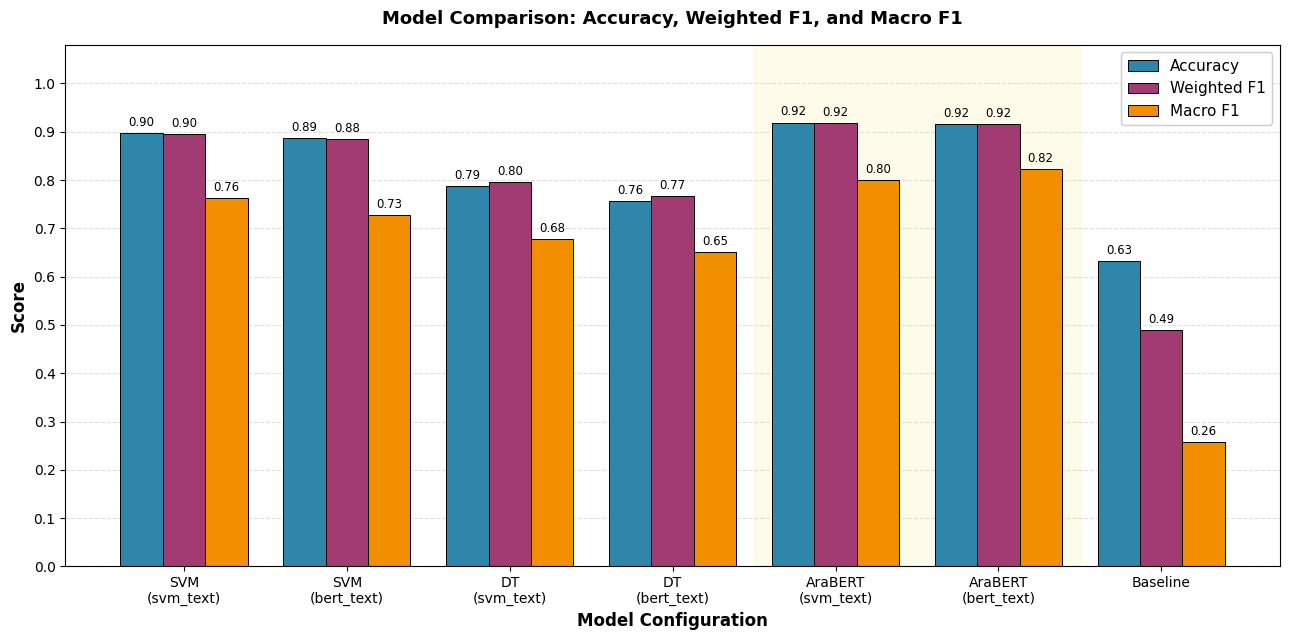


✅ انتهت الخلية


In [ ]:
# ============================================================
# CELL 16: إنشاء Figure 1 — Model Comparison Chart
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("="*70)
print("📈 إنشاء Figure 1")
print("="*70)

# ── البيانات ─────────────────────────────────────────────
models = [
    "SVM\n(svm_text)",
    "SVM\n(bert_text)",
    "DT\n(svm_text)",
    "DT\n(bert_text)",
    "AraBERT\n(svm_text)",
    "AraBERT\n(bert_text)",
    "Baseline",
]

accuracy = [0.8975, 0.8864, 0.7872, 0.7572, 0.9189, 0.9160, 0.6321]
weighted_f1 = [0.8956, 0.8843, 0.7956, 0.7663, 0.9180, 0.9160, 0.4896]
macro_f1 = [0.7622, 0.7267, 0.6784, 0.6514, 0.7998, 0.8234, 0.2582]

# ── إعدادات الشكل ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6.5))

x = np.arange(len(models))
width = 0.26  # عرض كل عمود

# ── الأعمدة ──────────────────────────────────────────────
bars1 = ax.bar(x - width, accuracy,    width, label="Accuracy",    color="#2E86AB", edgecolor="black", linewidth=0.7)
bars2 = ax.bar(x,         weighted_f1, width, label="Weighted F1", color="#A23B72", edgecolor="black", linewidth=0.7)
bars3 = ax.bar(x + width, macro_f1,    width, label="Macro F1",    color="#F18F01", edgecolor="black", linewidth=0.7)

# ── إضافة القيم فوق الأعمدة ──────────────────────────────
def add_labels(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.annotate(
            f"{val:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8.5,
        )

add_labels(bars1, accuracy)
add_labels(bars2, weighted_f1)
add_labels(bars3, macro_f1)

# ── تنسيقات ──────────────────────────────────────────────
ax.set_xlabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title(
    "Model Comparison: Accuracy, Weighted F1, and Macro F1",
    fontsize=13, fontweight="bold", pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.legend(loc="upper right", fontsize=11, framealpha=0.95)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# ── إبراز AraBERT ────────────────────────────────────────
# إضافة خلفية خفيفة على منطقة AraBERT
ax.axvspan(3.5, 5.5, alpha=0.08, color="gold", zorder=0)

plt.tight_layout()

# ── حفظ ──────────────────────────────────────────────────
plt.savefig("/content/Figure1_Model_Comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("/content/Figure1_Model_Comparison.pdf", bbox_inches="tight")

print("✅ حفظنا:")
print("   /content/Figure1_Model_Comparison.png")
print("   /content/Figure1_Model_Comparison.pdf")

plt.show()

print("\n" + "="*70)
print("✅ انتهت الخلية")
print("="*70)

In [ ]:
# ============================================================
# CELL 17: تحليل الـ Duplicates بالتفصيل
# ============================================================

import pandas as pd
import numpy as np
import re
import os

print("="*70)
print("🔍 تحليل الـ Duplicates بالتفصيل")
print("="*70)

# ── قراءة الملفين ─────────────────────────────────────────
print("\n📖 قراءة الملفات...")

# ملف original (8,536)
df_orig = pd.read_excel("/content/Tweets_Data.xlsx", engine="calamine")
print(f"✅ Tweets_Data.xlsx: {df_orig.shape}")

# ملف final (8,092)
df_final = pd.read_excel("/content/annotation fully completed.xlsx", engine="calamine")
print(f"✅ annotation fully completed.xlsx: {df_final.shape}")

# ── STEP 1: exact duplicates ──────────────────────────────
print("\n" + "="*70)
print("📊 1. Exact Duplicates (by tweet_id)")
print("="*70)

exact_dups_orig = df_orig["tweet_id"].duplicated().sum()
print(f"   في Tweets_Data: {exact_dups_orig}")

exact_dups_final = df_final["tweet_id"].duplicated().sum()
print(f"   في annotation: {exact_dups_final}")

# ── STEP 2: الفرق بين الملفين ─────────────────────────────
print("\n" + "="*70)
print("📊 2. الفرق بين الملفين")
print("="*70)

s_orig = set(df_orig["tweet_id"].astype(str))
s_final = set(df_final["tweet_id"].astype(str))

only_in_orig = s_orig - s_final
only_in_final = s_final - s_orig
common = s_orig & s_final

print(f"   عدد tweet_id في Tweets_Data فقط : {len(only_in_orig):,}")
print(f"   عدد tweet_id في annotation فقط  : {len(only_in_final):,}")
print(f"   عدد tweet_id مشترك              : {len(common):,}")
print(f"   إجمالي Tweets_Data              : {len(s_orig):,}")
print(f"   إجمالي annotation               : {len(s_final):,}")
print(f"   المحذوف (8,536 - 8,092)         : {len(s_orig) - len(s_final):,}")

# ── STEP 3: تحليل الـ 444 المحذوفة ────────────────────────
print("\n" + "="*70)
print("📊 3. تحليل الـ tweets المحذوفة ({:,} tweet)".format(len(only_in_orig)))
print("="*70)

# استخرج الصفوف المحذوفة من الملف الأصلي
df_removed = df_orig[df_orig["tweet_id"].astype(str).isin(only_in_orig)].copy()
print(f"   عدد الصفوف المحذوفة: {len(df_removed)}")

# تحليل المحذوف
if "text" in df_removed.columns:
    df_removed["text_str"] = df_removed["text"].astype(str)

    # كم منها فارغ/قصير جدًا
    df_removed["text_len"] = df_removed["text_str"].str.len()
    print(f"\n   طول النص:")
    print(f"   - min: {df_removed['text_len'].min()}")
    print(f"   - max: {df_removed['text_len'].max()}")
    print(f"   - mean: {df_removed['text_len'].mean():.1f}")
    print(f"   - median: {df_removed['text_len'].median():.1f}")

    short = (df_removed["text_len"] < 20).sum()
    print(f"\n   tweets أقل من 20 حرفًا: {short}")

# ── STEP 4: near-duplicates في الملف الأصلي ───────────────
print("\n" + "="*70)
print("📊 4. Near-Duplicates في Tweets_Data الأصلي")
print("="*70)

def normalize_text(text):
    """تطبيع النص للمقارنة"""
    text = str(text).lower()
    text = re.sub(r"https?://\S+", "", text)          # URLs
    text = re.sub(r"@\w+", "", text)                    # mentions
    text = re.sub(r"#\w+", "", text)                    # hashtags
    text = re.sub(r"\s+", " ", text).strip()           # whitespace
    return text

df_orig["text_normalized"] = df_orig["text"].apply(normalize_text)

# Near-duplicates: نفس النص بعد التطبيع
nd_count = df_orig["text_normalized"].duplicated().sum()
print(f"   عدد near-duplicates (نفس النص المُطبَّع): {nd_count}")
print(f"   نسبة near-duplicates من الأصلي: {nd_count / len(df_orig) * 100:.2f}%")

# كم مجموعة فريدة من near-duplicates؟
nd_groups = df_orig.groupby("text_normalized").size()
nd_groups = nd_groups[nd_groups > 1].sort_values(ascending=False)
print(f"   عدد مجموعات الـ near-duplicates: {len(nd_groups)}")

print(f"\n   أكثر 5 مجموعات (Top 5):")
for i, (text, count) in enumerate(nd_groups.head(5).items(), 1):
    print(f"   {i}. عدد النسخ: {count} | النص: {text[:100]}...")

# ── STEP 5: تحليل Categories / Topics للـ 444 المحذوفة ────
print("\n" + "="*70)
print("📊 5. توزيع الـ 444 المحذوفة حسب category")
print("="*70)

if "category" in df_removed.columns:
    print(df_removed["category"].value_counts())

print("\n   توزيع الـ 444 المحذوفة حسب topic (Top 10):")
if "topic" in df_removed.columns:
    print(df_removed["topic"].value_counts().head(10))

# ── STEP 6: matching pairs في train/test ──────────────────
print("\n" + "="*70)
print("📊 6. التأكد من عدم وجود duplicates بين train و test")
print("="*70)

train_df = pd.read_csv("/content/train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val.csv", encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test.csv", encoding="utf-8-sig")

# تطبيع النص
train_norm = set(train_df["original_text"].apply(normalize_text))
val_norm   = set(val_df["original_text"].apply(normalize_text))
test_norm  = set(test_df["original_text"].apply(normalize_text))

overlap_train_test = train_norm & test_norm
overlap_train_val  = train_norm & val_norm
overlap_val_test   = val_norm & test_norm

print(f"   overlap train ∩ test : {len(overlap_train_test)}")
print(f"   overlap train ∩ val  : {len(overlap_train_val)}")
print(f"   overlap val ∩ test   : {len(overlap_val_test)}")

if len(overlap_train_test) > 0:
    print(f"\n   ⚠️ يوجد {len(overlap_train_test)} نص متطابق بين train و test!")
    print("   هذه مشكلة data leakage — سنحتاج إصلاحها")
else:
    print("\n   ✅ لا يوجد data leakage بين train و test")

# ── STEP 7: الحفظ ─────────────────────────────────────────
print("\n" + "="*70)
print("📊 7. الحفظ")
print("="*70)

# حفظ قائمة الـ 444 المحذوفة
df_removed[["tweet_id", "text", "category", "topic"]].to_csv(
    "/content/removed_tweets_analysis.csv", index=False, encoding="utf-8-sig"
)
print("✅ حفظنا: removed_tweets_analysis.csv")

# حفظ ملخص
summary_dup = pd.DataFrame({
    "metric": [
        "total_original",
        "total_final",
        "removed_total",
        "exact_duplicates_in_original",
        "near_duplicates_in_original",
        "near_duplicate_groups",
        "overlap_train_test",
        "overlap_train_val",
        "overlap_val_test",
    ],
    "value": [
        len(df_orig),
        len(df_final),
        len(df_orig) - len(df_final),
        exact_dups_orig,
        nd_count,
        len(nd_groups),
        len(overlap_train_test),
        len(overlap_train_val),
        len(overlap_val_test),
    ],
})

summary_dup.to_csv("/content/duplicates_summary.csv", index=False)
print("✅ حفظنا: duplicates_summary.csv")

print("\n" + "="*70)
print("✅ انتهت الخلية 17")
print("="*70)

🔍 تحليل الـ Duplicates بالتفصيل

📖 قراءة الملفات...
✅ Tweets_Data.xlsx: (8536, 21)
✅ annotation fully completed.xlsx: (8092, 21)

📊 1. Exact Duplicates (by tweet_id)
   في Tweets_Data: 444
   في annotation: 0

📊 2. الفرق بين الملفين
   عدد tweet_id في Tweets_Data فقط : 0
   عدد tweet_id في annotation فقط  : 0
   عدد tweet_id مشترك              : 8,092
   إجمالي Tweets_Data              : 8,092
   إجمالي annotation               : 8,092
   المحذوف (8,536 - 8,092)         : 0

📊 3. تحليل الـ tweets المحذوفة (0 tweet)
   عدد الصفوف المحذوفة: 0

   طول النص:
   - min: nan
   - max: nan
   - mean: nan
   - median: nan

   tweets أقل من 20 حرفًا: 0

📊 4. Near-Duplicates في Tweets_Data الأصلي
   عدد near-duplicates (نفس النص المُطبَّع): 1392
   نسبة near-duplicates من الأصلي: 16.31%
   عدد مجموعات الـ near-duplicates: 919

   أكثر 5 مجموعات (Top 5):
   1. عدد النسخ: 33 | النص: التبرعات لدى مصرف الراجحي بإسم أمارة منطقة مكة المكرمة 458608010428255 sa 7880000458608010428255...
   2. عدد النسخ: 

In [ ]:
# ============================================================
# CELL 18: تنظيف البيانات + إعادة التقسيم الصحيح
# ============================================================

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GroupShuffleSplit

print("="*70)
print("🧹 تنظيف البيانات + إعادة التقسيم")
print("="*70)

# ── STEP 1: قراءة البيانات ────────────────────────────────
df = pd.read_excel("/content/annotation fully completed.xlsx", engine="calamine")
print(f"\n📖 البيانات الأصلية: {df.shape}")

# ── STEP 2: تطبيع النص لاكتشاف الـ near-duplicates ────────
def normalize_for_dedup(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["original_text"].apply(normalize_for_dedup)

# ── STEP 3: حذف exact duplicates (tweet_id) ───────────────
before = len(df)
df = df.drop_duplicates(subset="tweet_id", keep="first").copy()
after_id = len(df)
print(f"\n📊 بعد حذف exact duplicates (tweet_id): {after_id} (حُذف {before - after_id})")

# ── STEP 4: حذف near-duplicates ──────────────────────────
# الاحتفاظ بأول ظهور لكل نص مُطبَّع
before = len(df)
df = df.drop_duplicates(subset="text_norm", keep="first").copy()
after_text = len(df)
print(f"📊 بعد حذف near-duplicates (نص مُطبَّع): {after_text} (حُذف {before - after_text})")

# ── STEP 5: إعادة استخراج stance ──────────────────────────
STANCES = ["supportive", "critical", "neutral"]
def extract_stance(x):
    x = str(x).lower().strip()
    for s in STANCES:
        if x.endswith(s):
            return s
    return "UNKNOWN"

df["stance"] = df["adjudicated_label"].apply(extract_stance)
LABEL2ID = {"supportive": 0, "critical": 1, "neutral": 2}
df["label"] = df["stance"].map(LABEL2ID)
df = df[df["label"].notna()].copy()

print(f"\n📊 التوزيع النهائي:")
print(df["stance"].value_counts())

# ── STEP 6: GroupShuffleSplit (لتجنب data leakage) ────────
print("\n" + "="*70)
print("✂️ إعادة التقسيم مع GroupShuffleSplit")
print("="*70)

# المجموعة = text_norm (بحيث كل near-duplicate في نفس المجموعة)
groups = df["text_norm"].values

# Step 1: 80% train, 20% temp
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss1.split(df, df["label"], groups=groups))

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# Step 2: temp → 50% val, 50% test
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, temp_df["label"], groups=temp_df["text_norm"].values))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n✅ Train : {len(train_df):5,}")
print(f"✅ Val   : {len(val_df):5,}")
print(f"✅ Test  : {len(test_df):5,}")
print(f"✅ TOTAL : {len(df):5,}")

# ── STEP 7: التحقق من عدم وجود data leakage ──────────────
print("\n" + "="*70)
print("🔍 التحقق من Data Leakage")
print("="*70)

train_norm = set(train_df["text_norm"])
val_norm   = set(val_df["text_norm"])
test_norm  = set(test_df["text_norm"])

print(f"  train ∩ test: {len(train_norm & test_norm)}")
print(f"  train ∩ val : {len(train_norm & val_norm)}")
print(f"  val ∩ test  : {len(val_norm & test_norm)}")

if (len(train_norm & test_norm) == 0 and
    len(train_norm & val_norm) == 0 and
    len(val_norm & test_norm) == 0):
    print("\n✅ لا يوجد أي data leakage! ممتاز.")
else:
    print("\n⚠️ لا يزال هناك تسريب — نحتاج مراجعة")

# ── STEP 8: التوزيع الطبقي ─────────────────────────────────
print("\n" + "="*70)
print("📊 توزيع label في كل split")
print("="*70)

print(f"\n{'class':12s} | {'train':>8s} | {'val':>8s} | {'test':>8s}")
print("─" * 50)
for name, idx in LABEL2ID.items():
    n_train = (train_df["label"] == idx).sum()
    n_val = (val_df["label"] == idx).sum()
    n_test = (test_df["label"] == idx).sum()
    print(f"{name:12s} | {n_train:>8,} | {n_val:>8,} | {n_test:>8,}")

# ── STEP 9: حفظ الملفات الجديدة ───────────────────────────
train_df.to_csv("/content/train_v2.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("/content/val_v2.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("/content/test_v2.csv", index=False, encoding="utf-8-sig")

print("\n✅ حفظنا:")
print("   /content/train_v2.csv")
print("   /content/val_v2.csv")
print("   /content/test_v2.csv")

# ── STEP 10: ملخص ─────────────────────────────────────────
print("\n" + "="*70)
print("📊 ملخص التنظيف")
print("="*70)
print(f"  البيانات الأصلية (annotation)          : 8,092")
print(f"  بعد حذف exact duplicates (tweet_id)    : {after_id:,}")
print(f"  بعد حذف near-duplicates (text_norm)    : {after_text:,}")
print(f"  التوزيع النهائي:")
print(f"    Train: {len(train_df):,}")
print(f"    Val  : {len(val_df):,}")
print(f"    Test : {len(test_df):,}")
print("\n" + "="*70)
print("✅ انتهت الخلية 18")
print("="*70)

🧹 تنظيف البيانات + إعادة التقسيم

📖 البيانات الأصلية: (8092, 21)

📊 بعد حذف exact duplicates (tweet_id): 8092 (حُذف 0)
📊 بعد حذف near-duplicates (نص مُطبَّع): 6921 (حُذف 1171)

📊 التوزيع النهائي:
stance
supportive    4368
neutral       2401
critical       152
Name: count, dtype: int64

✂️ إعادة التقسيم مع GroupShuffleSplit

✅ Train : 5,536
✅ Val   :   692
✅ Test  :   693
✅ TOTAL : 6,921

🔍 التحقق من Data Leakage
  train ∩ test: 0
  train ∩ val : 0
  val ∩ test  : 0

✅ لا يوجد أي data leakage! ممتاز.

📊 توزيع label في كل split

class        |    train |      val |     test
──────────────────────────────────────────────────
supportive   |    3,495 |      439 |      434
critical     |      122 |       13 |       17
neutral      |    1,919 |      240 |      242

✅ حفظنا:
   /content/train_v2.csv
   /content/val_v2.csv
   /content/test_v2.csv

📊 ملخص التنظيف
  البيانات الأصلية (annotation)          : 8,092
  بعد حذف exact duplicates (tweet_id)    : 8,092
  بعد حذف near-duplicates (text_norm

In [ ]:
# ============================================================
# CELL 19: إعادة تدريب SVM + DT على البيانات الجديدة (v2)
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

print("="*70)
print("🔁 إعادة تدريب SVM + DT على البيانات الجديدة (v2)")
print("="*70)

# ── قراءة البيانات الجديدة ──────────────────────────────
train_df = pd.read_csv("/content/train_v2.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val_v2.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test_v2.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

print(f"\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# ── دالة تشغيل موديل واحد ────────────────────────────────
def run_model(model_type, text_col, seed):
    X_train = train_df[text_col].values
    y_train = train_df["label"].values
    X_val   = val_df[text_col].values
    y_val   = val_df["label"].values
    X_test  = test_df[text_col].values
    y_test  = test_df["label"].values

    tfidf = TfidfVectorizer(
        max_features=20000, ngram_range=(1,2),
        min_df=2, sublinear_tf=True,
    )
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf   = tfidf.transform(X_val)
    X_test_tfidf  = tfidf.transform(X_test)

    if model_type == "SVM":
        clf = LinearSVC(class_weight="balanced", random_state=seed, max_iter=5000)
    else:
        clf = DecisionTreeClassifier(
            max_depth=30, min_samples_split=5,
            class_weight="balanced", random_state=seed,
        )

    clf.fit(X_train_tfidf, y_train)

    y_val_pred  = clf.predict(X_val_tfidf)
    y_test_pred = clf.predict(X_test_tfidf)

    return {
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_f1_weighted": f1_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "val_f1_macro": f1_score(y_val, y_val_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, y_test_pred),
        "f1_weighted": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "critical_recall": classification_report(
            y_test, y_test_pred, target_names=["supportive","critical","neutral"],
            output_dict=True, zero_division=0
        )["critical"]["recall"],
        "critical_f1": classification_report(
            y_test, y_test_pred, target_names=["supportive","critical","neutral"],
            output_dict=True, zero_division=0
        )["critical"]["f1-score"],
        "y_test": y_test,
        "y_test_pred": y_test_pred,
    }

# ── تشغيل 4 configs × 3 seeds ─────────────────────────────
SEEDS = [42, 1, 2024]
configs = [
    ("SVM", "svm_text"),
    ("SVM", "bert_text"),
    ("DT", "svm_text"),
    ("DT", "bert_text"),
]

all_results = []

for model_type, text_col in configs:
    print(f"\n{'─'*70}")
    print(f"🔹 {model_type} + {text_col}")
    print(f"{'─'*70}")

    for seed in SEEDS:
        res = run_model(model_type, text_col, seed)
        res["model"] = f"{model_type}_{text_col}"
        res["seed"] = seed
        all_results.append(res)
        print(f"   seed={seed:5d} | Acc={res['accuracy']:.4f} | W-F1={res['f1_weighted']:.4f} | M-F1={res['f1_macro']:.4f} | Crit-F1={res['critical_f1']:.4f} | Crit-R={res['critical_recall']:.4f}")

# ── mean ± std ────────────────────────────────────────────
print("\n" + "="*70)
print("📊 Mean ± Std (v2)")
print("="*70)

df_seeds = pd.DataFrame(all_results)
summary_seeds = df_seeds.groupby("model").agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    f1_weighted_mean=("f1_weighted", "mean"),
    f1_weighted_std=("f1_weighted", "std"),
    f1_macro_mean=("f1_macro", "mean"),
    f1_macro_std=("f1_macro", "std"),
    critical_f1_mean=("critical_f1", "mean"),
    critical_f1_std=("critical_f1", "std"),
    critical_recall_mean=("critical_recall", "mean"),
    critical_recall_std=("critical_recall", "std"),
).reset_index()

print("\n" + summary_seeds.to_string(index=False))

# ── حفظ ──────────────────────────────────────────────────
df_seeds.to_csv("/content/seeds_v2_SVM_DT.csv", index=False)
summary_seeds.to_csv("/content/seeds_summary_v2_SVM_DT.csv", index=False)

# حفظ predictions من seed 42
for model_type, text_col in configs:
    for r in all_results:
        if r["model"] == f"{model_type}_{text_col}" and r["seed"] == 42:
            pd.DataFrame({
                "y_true": r["y_test"],
                "y_pred": r["y_test_pred"],
            }).to_csv(f"/content/pred_v2_{model_type}_{text_col}.csv", index=False)

print("\n✅ حفظنا:")
print("   seeds_v2_SVM_DT.csv")
print("   seeds_summary_v2_SVM_DT.csv")
print("   pred_v2_*.csv (6 ملفات)")

print("\n" + "="*70)
print("✅ انتهت الخلية 19")
print("="*70)

🔁 إعادة تدريب SVM + DT على البيانات الجديدة (v2)

Train: 5,536 | Val: 692 | Test: 693

──────────────────────────────────────────────────────────────────────
🔹 SVM + svm_text
──────────────────────────────────────────────────────────────────────
   seed=   42 | Acc=0.8312 | W-F1=0.8286 | M-F1=0.6879 | Crit-F1=0.4167 | Crit-R=0.2941
   seed=    1 | Acc=0.8312 | W-F1=0.8286 | M-F1=0.6879 | Crit-F1=0.4167 | Crit-R=0.2941
   seed= 2024 | Acc=0.8312 | W-F1=0.8286 | M-F1=0.6879 | Crit-F1=0.4167 | Crit-R=0.2941

──────────────────────────────────────────────────────────────────────
🔹 SVM + bert_text
──────────────────────────────────────────────────────────────────────
   seed=   42 | Acc=0.8312 | W-F1=0.8268 | M-F1=0.6406 | Crit-F1=0.2727 | Crit-R=0.1765
   seed=    1 | Acc=0.8312 | W-F1=0.8268 | M-F1=0.6406 | Crit-F1=0.2727 | Crit-R=0.1765
   seed= 2024 | Acc=0.8312 | W-F1=0.8268 | M-F1=0.6406 | Crit-F1=0.2727 | Crit-R=0.1765

────────────────────────────────────────────────────────────────

In [ ]:
# ============================================================
# CELL 20: إعادة تدريب AraBERT على v2
# ============================================================

import torch
import numpy as np
import pandas as pd
import random, time
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

print("="*70)
print("🤖 AraBERT على البيانات الجديدة (v2)")
print("="*70)

# ── قراءة البيانات ─────────────────────────────────────
train_df = pd.read_csv("/content/train_v2.csv", encoding="utf-8-sig")
val_df   = pd.read_csv("/content/val_v2.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test_v2.csv",  encoding="utf-8-sig")

for d in [train_df, val_df, test_df]:
    d["svm_text"]  = d["svm_text"].fillna("").astype(str)
    d["bert_text"] = d["bert_text"].fillna("").astype(str)

# ── Class Weights ──────────────────────────────────────
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"\n⚖️ Class Weights:")
for i, w in enumerate(class_weights):
    label_name = ["supportive", "critical", "neutral"][i]
    print(f"  {i} = {label_name:12s} : {w:.4f}")

# ── Tokenizer ──────────────────────────────────────────
MODEL_NAME = "aubmindlab/bert-base-arabertv02-twitter"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
WEIGHT_DECAY = 0.01

# ── Dataset ────────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=MAX_LEN, return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

def make_datasets(text_col):
    return (
        TweetDataset(train_df[text_col].values, train_df["label"].values),
        TweetDataset(val_df[text_col].values,   val_df["label"].values),
        TweetDataset(test_df[text_col].values,  test_df["label"].values),
    )

# ── دالة التدريب ───────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_arabert(text_col, seed):
    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3,
        id2label={0:"supportive",1:"critical",2:"neutral"},
        label2id={"supportive":0,"critical":1,"neutral":2},
    ).to(device)

    train_ds, val_ds, test_ds = make_datasets(text_col)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1*total_steps),
        num_training_steps=total_steps,
    )
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

    def evaluate(model, loader):
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in loader:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                y = batch["labels"].to(device)
                logits = model(input_ids=ids, attention_mask=mask).logits
                preds.extend(torch.argmax(logits,1).cpu().numpy())
                labels.extend(y.cpu().numpy())
        return preds, labels

    best_val_macro = 0
    best_state = None
    best_epoch = -1

    for epoch in range(1, EPOCHS+1):
        model.train()
        for batch in train_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(input_ids=ids, attention_mask=mask).logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        vp, vl = evaluate(model, val_loader)
        vm = f1_score(vl, vp, average="macro", zero_division=0)
        print(f"   Epoch {epoch}: Val Macro F1 = {vm:.4f}")

        if vm > best_val_macro:
            best_val_macro = vm
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state); model.to(device)
    tp, tl = evaluate(model, test_loader)

    return {
        "accuracy": accuracy_score(tl, tp),
        "f1_weighted": f1_score(tl, tp, average="weighted", zero_division=0),
        "f1_macro": f1_score(tl, tp, average="macro", zero_division=0),
        "critical_f1": classification_report(
            tl, tp, target_names=["supportive","critical","neutral"],
            output_dict=True, zero_division=0
        )["critical"]["f1-score"],
        "critical_recall": classification_report(
            tl, tp, target_names=["supportive","critical","neutral"],
            output_dict=True, zero_division=0
        )["critical"]["recall"],
        "best_epoch": best_epoch,
        "y_test": tl, "y_test_pred": tp,
    }

# ── تشغيل 2 configs × 3 seeds ─────────────────────────
SEEDS = [42, 1, 2024]
configs = ["svm_text", "bert_text"]
all_results = []

for text_col in configs:
    print(f"\n{'─'*70}")
    print(f"🔹 AraBERT + {text_col}")
    print(f"{'─'*70}")

    for seed in SEEDS:
        print(f"\n  Seed = {seed}")
        t0 = time.time()
        res = train_arabert(text_col, seed)
        res["model"] = f"AraBERT_{text_col}"
        res["seed"] = seed
        all_results.append(res)
        print(f"  ✅ Acc={res['accuracy']:.4f} | W-F1={res['f1_weighted']:.4f} | M-F1={res['f1_macro']:.4f} | Crit-F1={res['critical_f1']:.4f} | Crit-R={res['critical_recall']:.4f} | Best={res['best_epoch']} | {time.time()-t0:.0f}s")

# ── mean ± std ────────────────────────────────────────
print("\n" + "="*70)
print("📊 AraBERT v2 — Mean ± Std")
print("="*70)

df_seeds = pd.DataFrame(all_results)
summary_seeds = df_seeds.groupby("model").agg(
    accuracy_mean=("accuracy","mean"), accuracy_std=("accuracy","std"),
    f1_weighted_mean=("f1_weighted","mean"), f1_weighted_std=("f1_weighted","std"),
    f1_macro_mean=("f1_macro","mean"), f1_macro_std=("f1_macro","std"),
    critical_f1_mean=("critical_f1","mean"), critical_f1_std=("critical_f1","std"),
    critical_recall_mean=("critical_recall","mean"), critical_recall_std=("critical_recall","std"),
).reset_index()

print("\n" + summary_seeds.to_string(index=False))

df_seeds.drop(columns=["y_test","y_test_pred"]).to_csv("/content/seeds_v2_AraBERT.csv", index=False)
summary_seeds.to_csv("/content/seeds_summary_v2_AraBERT.csv", index=False)

# حفظ predictions seed 42
for r in all_results:
    if r["seed"] == 42:
        pd.DataFrame({"y_true": r["y_test"], "y_pred": r["y_test_pred"]}).to_csv(
            f"/content/pred_v2_{r['model']}.csv", index=False
        )

print("\n✅ حفظنا كل النتائج")
print("="*70)

🤖 AraBERT على البيانات الجديدة (v2)

⚖️ Class Weights:
  0 = supportive   : 0.5280
  1 = critical     : 15.1257
  2 = neutral      : 0.9616

──────────────────────────────────────────────────────────────────────
🔹 AraBERT + svm_text
──────────────────────────────────────────────────────────────────────

  Seed = 42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1: Val Macro F1 = 0.5823
   Epoch 2: Val Macro F1 = 0.7422
   Epoch 3: Val Macro F1 = 0.7362
  ✅ Acc=0.8571 | W-F1=0.8551 | M-F1=0.7496 | Crit-F1=0.5556 | Crit-R=0.5882 | Best=2 | 405s

  Seed = 1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1: Val Macro F1 = 0.5971
   Epoch 2: Val Macro F1 = 0.7496
   Epoch 3: Val Macro F1 = 0.7449
  ✅ Acc=0.8802 | W-F1=0.8805 | M-F1=0.7695 | Crit-F1=0.5556 | Crit-R=0.5882 | Best=2 | 417s

  Seed = 2024


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1: Val Macro F1 = 0.7243
   Epoch 2: Val Macro F1 = 0.7753
   Epoch 3: Val Macro F1 = 0.7727
  ✅ Acc=0.8903 | W-F1=0.8909 | M-F1=0.8124 | Crit-F1=0.6667 | Crit-R=0.7059 | Best=2 | 417s

📊 AraBERT v2 — Mean ± Std

            model  accuracy_mean  accuracy_std  f1_weighted_mean  f1_weighted_std  f1_macro_mean  f1_macro_std  critical_f1_mean  critical_f1_std  critical_recall_mean  critical_recall_std
AraBERT_bert_text         0.8846        0.0052            0.8849           0.0053         0.7924        0.0216            0.6169           0.0565                0.6471               0.0588
 AraBERT_svm_text         0.8812        0.0238            0.8804           0.0245         0.7805        0.0334            0.5907           0.0478                0.5882               0.0000

✅ حفظنا كل النتائج


In [ ]:
# ============================================================
# CELL 21: Majority Baseline على v2
# ============================================================

import pandas as pd
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("="*70)
print("📊 Majority Baseline (v2)")
print("="*70)

train_df = pd.read_csv("/content/train_v2.csv", encoding="utf-8-sig")
test_df  = pd.read_csv("/content/test_v2.csv",  encoding="utf-8-sig")

X_train = train_df["svm_text"].fillna("").astype(str).values
y_train = train_df["label"].values
X_test  = test_df["svm_text"].fillna("").astype(str).values
y_test  = test_df["label"].values

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"\n  Accuracy    : {acc:.4f}")
print(f"  Weighted F1 : {f1w:.4f}")
print(f"  Macro F1    : {f1m:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=["supportive","critical","neutral"], digits=4, zero_division=0))

pd.DataFrame([{
    "model": "Majority_Baseline",
    "accuracy": acc,
    "f1_weighted": f1w,
    "f1_macro": f1m,
}]).to_csv("/content/baseline_v2.csv", index=False)

print("\n✅ حفظنا: baseline_v2.csv")
print("="*70)

📊 Majority Baseline (v2)

  Accuracy    : 0.6263
  Weighted F1 : 0.4823
  Macro F1    : 0.2567

  Classification Report:
              precision    recall  f1-score   support

  supportive     0.6263    1.0000    0.7702       434
    critical     0.0000    0.0000    0.0000        17
     neutral     0.0000    0.0000    0.0000       242

    accuracy                         0.6263       693
   macro avg     0.2088    0.3333    0.2567       693
weighted avg     0.3922    0.6263    0.4823       693


✅ حفظنا: baseline_v2.csv


In [ ]:
# ============================================================
# CELL 22: الجدول النهائي الكامل (v2)
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print("📊 الجدول النهائي الكامل (v2)")
print("="*70)

# ── قراءة كل النتائج ─────────────────────────────────
svm_dt = pd.read_csv("/content/seeds_summary_v2_SVM_DT.csv")
arabert = pd.read_csv("/content/seeds_summary_v2_AraBERT.csv")
baseline = pd.read_csv("/content/baseline_v2.csv")

# ── تجهيز الأعمدة ─────────────────────────────────────
def prep(df):
    return pd.DataFrame({
        "model": df["model"],
        "accuracy_mean": df["accuracy_mean"],
        "accuracy_std": df["accuracy_std"],
        "f1_weighted_mean": df["f1_weighted_mean"],
        "f1_weighted_std": df["f1_weighted_std"],
        "f1_macro_mean": df["f1_macro_mean"],
        "f1_macro_std": df["f1_macro_std"],
        "critical_f1_mean": df["critical_f1_mean"],
        "critical_f1_std": df["critical_f1_std"],
        "critical_recall_mean": df["critical_recall_mean"],
        "critical_recall_std": df["critical_recall_std"],
    })

baseline_row = pd.DataFrame([{
    "model": "Majority_Baseline",
    "accuracy_mean": baseline["accuracy"].values[0],
    "accuracy_std": 0.0,
    "f1_weighted_mean": baseline["f1_weighted"].values[0],
    "f1_weighted_std": 0.0,
    "f1_macro_mean": baseline["f1_macro"].values[0],
    "f1_macro_std": 0.0,
    "critical_f1_mean": 0.0,
    "critical_f1_std": 0.0,
    "critical_recall_mean": 0.0,
    "critical_recall_std": 0.0,
}])

final = pd.concat([prep(svm_dt), prep(arabert), baseline_row], ignore_index=True)

# ترتيب
order = [
    "SVM_svm_text", "SVM_bert_text",
    "DT_svm_text", "DT_bert_text",
    "AraBERT_svm_text", "AraBERT_bert_text",
    "Majority_Baseline",
]
final["model"] = pd.Categorical(final["model"], categories=order, ordered=True)
final = final.sort_values("model").reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("\n" + final.to_string(index=False))

final.to_csv("/content/FINAL_RESULTS_TABLE_v2.csv", index=False)
print("\n✅ حفظنا: FINAL_RESULTS_TABLE_v2.csv")
print("="*70)

📊 الجدول النهائي الكامل (v2)

            model  accuracy_mean  accuracy_std  f1_weighted_mean  f1_weighted_std  f1_macro_mean  f1_macro_std  critical_f1_mean  critical_f1_std  critical_recall_mean  critical_recall_std
     SVM_svm_text         0.8312        0.0000            0.8286           0.0000         0.6879        0.0000            0.4167           0.0000                0.2941               0.0000
    SVM_bert_text         0.8312        0.0000            0.8268           0.0000         0.6406        0.0000            0.2727           0.0000                0.1765               0.0000
      DT_svm_text         0.7547        0.0090            0.7612           0.0085         0.6753        0.0155            0.5085           0.0304                0.6078               0.0340
     DT_bert_text         0.7177        0.0036            0.7227           0.0031         0.5797        0.0178            0.2883           0.0495                0.2549               0.0340
 AraBERT_svm_text        